# 🚲 Bike Sharing Demand Prediction - Capstone Project M2
**Capital Bikeshare | Washington D.C. | Hourly Rental Forecast**

---

## Table of Contents

1. Business Problem Understanding
2. Data Understanding
3. EDA (Exploratory Data Analysis)
4. Data Preprocessing
5. Modeling
6. Conclusion
7. Recommendation

---

# **1. Business Problem Understanding**

## 📌 **Context**

Bike-sharing adalah sistem penyewaan sepeda berbasis teknologi yang memungkinkan pengguna menyewa sepeda dari satu stasiun dan mengembalikannya di stasiun lain tanpa perlu interaksi manual dengan petugas. Seluruh proses, mulai dari registrasi keanggotaan, peminjaman, hingga pengembalian, dilakukan secara digital dan tercatat otomatis oleh sistem.

**Capital Bikeshare** adalah salah satu sistem bike-sharing yang beroperasi di wilayah Washington D.C. dan sekitarnya. Sistem ini melayani dua tipe pengguna:

- **Casual Users**: Pengguna non-anggota yang menyewa sepeda secara insidental (wisatawan, pengguna sesekali).
- **Registered Users**: Anggota berlangganan yang menggunakan sepeda untuk keperluan rutin seperti commuting.

Dataset yang digunakan dalam project ini merekam data penyewaan sepeda **per jam** selama periode 2011-2012, dilengkapi dengan informasi kondisi cuaca, musim, hari libur, dan waktu. Data ini bersumber dari Capital Bikeshare (capitalbikeshare.com/system-data), sedangkan data cuaca diperoleh dari freemeteo.com.

Sebagai sistem transportasi publik yang terus berkembang -- Dengan lebih dari 500 program bike-sharing di seluruh dunia dan lebih dari 500.000 sepeda aktif pada saat dataset ini dibuat -- Kemampuan memprediksi permintaan secara akurat menjadi kebutuhan kritis bagi operator untuk menjaga kualitas layanan dan efisiensi operasional.

## ❗️ **Problem Statement**

Tantangan terbesar yang dihadapi operator bike-sharing seperti Capital Bikeshare adalah **ketidakpastian permintaan yang berfluktuasi secara dinamis** setiap jamnya. Permintaan penyewaan sepeda sangat dipengaruhi oleh kombinasi faktor seperti jam operasional, kondisi cuaca, hari kerja vs hari libur, dan musim, yang membuat pola permintaan sulit diprediksi secara intuitif.

Kondisi ini menimbulkan dua permasalahan operasional utama yang berdampak langsung pada bisnis:

1. **Under-Supply (Kekurangan sepeda di stasiun):** Terjadi ketika permintaan aktual melebihi ketersediaan sepeda di suatu stasiun. Akibatnya, calon penyewa tidak terlayani, yang berpotensi meningkatkan *churn rate* dan menurunkan kepuasan pengguna (*user satisfaction*).

2. **Over-Supply (Penumpukan sepeda di stasiun):** Terjadi ketika terlalu banyak sepeda menumpuk di stasiun tertentu -- Baik karena kesalahan alokasi awal maupun karena pengguna secara alami mengembalikan sepeda ke stasiun yang berbeda dari tempat mereka meminjam (*one-way trips*). Hal ini menyebabkan inefisiensi biaya operasional, terutama biaya redistribusi sepeda (*rebalancing cost*) antar stasiun yang dilakukan operator secara berkala menggunakan kendaraan khusus.

**Tanpa sistem prediksi permintaan yang andal, operator terpaksa mengandalkan distribusi manual berdasarkan intuisi, yang rawan terhadap kedua risiko di atas secara bersamaan.**

Oleh karena itu, dibutuhkan sebuah model prediktif yang mampu memperkirakan **jumlah total penyewaan sepeda per jam** berdasarkan kondisi lingkungan dan temporal, sehingga operator dapat merencanakan distribusi sepeda secara proaktif dan data-driven.

## 🎯 **Goals**

Berdasarkan problem statement di atas, tujuan utama dari project ini adalah:

**Membangun model machine learning berbasis regresi yang mampu memprediksi jumlah total penyewaan sepeda `(cnt)` per jam secara akurat**, dengan memanfaatkan fitur-fitur temporal (jam, musim, hari libur) dan kondisi cuaca (suhu, kelembaban, situasi cuaca).

Model ini diharapkan dapat digunakan oleh tim operasional Capital Bikeshare untuk:

- **Perencanaan distribusi sepeda** secara proaktif dengan menentukan jumlah sepeda yang perlu tersedia di setiap stasiun pada jam-jam tertentu.
- **Optimasi jadwal rebalancing** (redistribusi sepeda antar stasiun) berdasarkan pola prediksi permintaan per jam, sehingga operator dapat merencanakan kapan dan di mana redistribusi perlu dilakukan sebelum ketidakseimbangan terjadi.
- **Efisiensi biaya operasional** dengan mengurangi frekuensi redistribusi darurat akibat mismatch antara supply dan demand.
- **Mengurangi lost revenue** akibat kekurangan stok di jam-jam sibuk.
- **Peningkatan service level** dengan memastikan sepeda tersedia saat dibutuhkan, khususnya pada jam-jam puncak (peak hours).

> 📌 **Catatan scope:** Model ini memprediksi total permintaan di tingkat sistem secara keseluruhan (bukan per stasiun), sehingga output-nya paling tepat digunakan sebagai dasar perencanaan jadwal rebalancing untuk mengantisipasi lonjakan atau penurunan demand sebelum terjadi, bukan untuk menentukan stasiun mana yang kekurangan atau kelebihan sepeda secara spesifik.

Secara kuantitatif, model yang dibangun ditargetkan memenuhi tiga kriteria berikut:

**1. RMSE minimal 50% lebih baik dari baseline Linear Regression**

Linear Regression dipilih sebagai baseline karena merupakan model regresi paling sederhana yang bisa diimplementasikan pada dataset ini -- Mengasumsikan hubungan linear antar seluruh fitur dan target. Dataset ini memiliki pola non-linear yang jelas -- Bimodal demand di rush hour, interaksi suhu dan musim, serta pola cyclical per jam -- Yang secara fundamental tidak bisa ditangkap model linear.

Improvement minimal 50% ditetapkan sebagai treshold yang membuktikan model yang lebih kompleks memang memberikan nilai tambah nyata dan kompleksitas tambahannya justified secara teknis.
*(Target RMSE baseline LR dievaluasi setelah baseline dijalankan di Section 5.)*

**2. MAE minimal 50% lebih baik dari MAE Naive Baseline (Target MAE ≤ 87.63 sepeda)**

Sebagai patokan pembanding, digunakan naive baseline -- Yaitu pendekatan tanpa model sama sekali, di mana setiap jam diprediksi memiliki demand yang sama dengan rata-rata historis training data (175 sepeda/jam), tanpa mempertimbangkan kondisi temporal, cuaca, maupun karakteristik hari operasional. MAE naive baseline pada dataset ini adalah 175.27 sepeda, sehingga target model ditetapkan MAE ≤ 87.63 sepeda (50% lebih baik dari naive).

Treshold 50% dipilih karena jika model yang telah dilatih dengan data, fitur, dan tuning masih meleset hampir sebesar pendekatan tanpa model, tidak ada justifikasi bisnis untuk menginvestasikan resource dalam pengembangannya. Model yang melampaui treshold ini terbukti telah mempelajari pola demand yang sesungguhnya dan memberikan nilai prediktif yang nyata.

**3. R² di atas 0.85**

Model harus mampu menjelaskan minimal 85% variasi pola demand sepanjang hari -- Memastikan model tidak hanya akurat secara rata-rata, tapi juga mengikuti fluktuasi demand yang terjadi dari kondisi permintaan rendah hingga lonjakan pada jam-jam puncak operasional. Treshold 0.85 ditetapkan karena dataset ini memiliki pola temporal yang sangat terstruktur dan berulang -- Rush hour yang konsisten setiap hari kerja, perbedaan weekday dan weekend yang jelas, serta seasonality yang terpola -- Sehingga model yang baik seharusnya mampu menangkap sebagian besar variansi tersebut. Nilai di bawah 0.85 mengindikasikan model gagal menangkap pola utama yang seharusnya bisa dipelajari dari data ini.

## 🔍 **Analytic Approach**

Untuk menjawab permasalahan di atas, pendekatan analitik yang digunakan adalah **supervised machine learning dengan metode regresi**.

Alasan pemilihan pendekatan regresi:

- Target variabel `(cnt)` merupakan bilangan bulat kontinu yang merepresentasikan **jumlah penyewaan sepeda** -- Bukan kategori. Regresi adalah pendekatan yang paling tepat untuk memprediksi nilai numerik.
- Nilai prediksi yang dihasilkan secara langsung dapat diinterpretasikan dalam satuan nyata (jumlah sepeda), sehingga **actionable** bagi tim operasional.
- Klasifikasi (misal: Low/Medium/High demand) akan kehilangan presisi kuantitatif yang justru dibutuhkan untuk perencanaan alokasi sepeda.

**Alur analitik yang akan dilakukan:**

1. **Eksplorasi & Pemahaman Data** -- Memahami distribusi, tren, dan hubungan antar fitur dengan target variabel `(cnt)`.
2. **Data Cleaning & Preprocessing** -- Menangani missing values, outlier, encoding variabel categorical, dan normalisasi/scaling.
3. **Feature Engineering** -- Mengekstrak informasi temporal dari kolom waktu (misal: rush hour, weekend flag) dan menangani fitur cyclical (jam).
4. **Pemodelan & Evaluasi** -- Melatih beberapa algoritma regresi (baseline hingga ensemble), membandingkan performa, dan melakukan hyperparameter tuning pada model terbaik.
5. **Interpretasi & Rekomendasi** -- Menganalisis feature importance dan memberikan rekomendasi bisnis berdasarkan hasil model.

> ⚠️ **Catatan Penting:** Kolom `(casual)` dan `(registered)` **tidak akan digunakan** sebagai fitur, karena keduanya adalah komponen penyusun dari target variabel `(cnt)` -> `(casual + registered = cnt)`. Menggunakannya sebagai fitur akan menyebabkan **target leakage** yang membuat evaluasi model tidak valid.

## 📊 **Metric Evaluation**

Metrik evaluasi yang digunakan untuk mengukur performa model regresi dalam project ini adalah sebagai berikut:

---

**1. RMSE - Root Mean Squared Error**

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

RMSE memberikan penalti yang lebih besar pada error yang besar karena error dikuadratkan sebelum dirata-ratakan. Ini lebih sesuai dengan konteks bike-sharing di mana kesalahan prediksi berskala besar berdampak langsung pada ketersediaan sepeda dan kualitas layanan. RMSE selalu bernilai ≥ MAE -- Selisih besar antara keduanya mengindikasikan adanya error ekstrem yang signifikan.

> ⚠️ **Limitasi RMSE:** Sensitivitas tinggi terhadap outlier menjadi pedang bermata dua -- beberapa prediksi yang meleset jauh dapat mendominasi nilai RMSE secara keseluruhan, sehingga performa model bisa terlihat lebih buruk dari kenyataannya jika terdapat outlier pada data.

---

**2. MAE - Mean Absolute Error**

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

MAE mengukur rata-rata selisih absolut antara nilai aktual dan nilai prediksi. Interpretasinya intuitif: jika MAE = 50, artinya rata-rata prediksi model meleset sebesar 50 sepeda dari jumlah aktual.

> ⚠️ **Limitasi MAE:** MAE memperlakukan semua error secara setara tanpa membedakan error kecil dan error besar. Dalam konteks operasional bike-sharing, meleset 100 sepeda jauh lebih berdampak daripada meleset 5 sepeda -- Namun MAE tidak mencerminkan perbedaan dampak ini.

---

**3. R² - Coefficient of Determination**

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

R² mengukur seberapa besar proporsi variansi target yang berhasil dijelaskan oleh model. Nilainya berkisar antara 0 hingga 1 -- Semakin mendekati 1, semakin baik model menangkap pola data.

Jika R² = 0.85, artinya model berhasil menjelaskan 85% dari fluktuasi demand penyewaan sepeda, dan hanya 15% yang tidak tertangkap oleh fitur yang ada.

> ⚠️ **Limitasi R²:** R² tidak memberikan informasi tentang besarnya error dalam satuan yang operasional (sepeda). Model dengan R² tinggi belum tentu memiliki error yang kecil secara absolut. Itulah kenapa R² digunakan sebagai metrik pelengkap, bukan metrik utama.

---

**Prioritas metrik:** RMSE dipilih sebagai metrik utama dalam proses pemilihan dan perbandingan model, karena sensitivitasnya terhadap error besar lebih mencerminkan dampak nyata di operasional bike-sharing. MAE digunakan sebagai acuan operasional dan pembanding RMSE untuk mendeteksi error ekstrem. Jika RMSE jauh lebih besar dari MAE, ada indikasi error ekstrem yang perlu diinvestigasi. R² digunakan sebagai informasi tambahan seberapa baik model menangkap pola keseluruhan data.

## ⚙️ Import Library

In [1]:
# --- Install Library ---
!pip install scikit-optimize xgboost lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.0 MB/s eta 0:00:00


In [2]:
# --- Data Manipulation ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Utility ---
import time               # Mengukur Waktu Eksekusi
import joblib             # Simpan dan Load Model
from typing import Union  # Type Hint untuk Multiple Tipe

# --- Preprocessing ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    cross_val_score,
    RandomizedSearchCV,
    TimeSeriesSplit  # CV Strategy untuk Data Temporal
)

# --- Distribusi untuk RandomizedSearchCV ---
from scipy.stats import randint, uniform, loguniform

# --- Pipeline ---
from sklearn.pipeline import Pipeline

# --- Modeling ---
from sklearn.base import BaseEstimator             # Type Hint untuk Model
from sklearn.linear_model import LinearRegression  # Baseline
from sklearn.tree import DecisionTreeRegressor     # Stepping Stone
from sklearn.ensemble import (
    RandomForestRegressor,                         # Ensemble
    GradientBoostingRegressor                      # Ensemble
)
from xgboost import XGBRegressor                   # Ensemble
from lightgbm import LGBMRegressor                 # Ensemble

# --- Bayesian Optimization ---
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical  # Tipe Ruang Parameter Bayes

# --- Evaluation Metrics ---
from sklearn.metrics import (
    mean_absolute_error,             # MAE
    mean_squared_error,              # MSE -> (di-sqrt untuk RMSE)
    r2_score                         # R²
)

# --- Ignore Warnings ---
import warnings
warnings.filterwarnings('ignore')

# --- Konfigurasi Tampilan ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

# **2. Data Understanding**

## 2.1 Deskripsi Dataset

- Dataset berisi data penyewaan sepeda **per jam** dari sistem Capital Bikeshare di Washington D.C., mencakup periode **tahun 2011 hingga tahun 2012**.
- Setiap baris merepresentasikan **satu jam operasional** pada suatu hari tertentu, beserta kondisi cuaca dan jumlah sepeda yang disewa pada jam tersebut.
- Total data: **12.165 baris** dan **11 kolom**.

---

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| `dteday` | String (Date) | Tanggal pencatatan (format: YYYY-MM-DD) |
| `season` | Integer (Kategorikal) | Musim: 1=Winter, 2=Spring, 3=Summer, 4=Fall |
| `hr` | Integer | Jam dalam sehari (0-23) |
| `holiday` | Integer (Binary) | Apakah hari tersebut hari libur: 0=Tidak, 1=Ya |
| `weathersit` | Integer (Kategorikal) | Kondisi cuaca (1-4, semakin besar semakin buruk) |
| `temp` | Float | Suhu ternormalisasi (0-1), aktual: -8°C hingga +39°C |
| `atemp` | Float | Suhu terasa ternormalisasi (0-1), aktual: -16°C hingga +50°C |
| `hum` | Float | Kelembaban ternormalisasi (0-1), aktual: 0% hingga 100% |
| `casual` | Integer | Jumlah penyewa non-anggota (casual users) |
| `registered` | Integer | Jumlah penyewa anggota (registered users) |
| `cnt` | Integer | **TARGET** -> Total penyewaan = casual + registered |

> ⚠️ **Catatan penting:** `casual` dan `registered` adalah komponen penyusun `cnt` secara langsung (`casual + registered = cnt`). Keduanya **tidak akan digunakan sebagai fitur** dalam pemodelan karena akan menyebabkan target leakage.

---

**Detail kondisi cuaca (`weathersit`):**

| Nilai | Kondisi |
|---|---|
| 1 | Cerah, sedikit awan, sebagian berawan |
| 2 | Berkabut + berawan, berkabut + awan pecah, berkabut + sedikit awan, berkabut |
| 3 | Salju ringan, hujan ringan + petir + awan tersebar, hujan ringan + awan tersebar |
| 4 | Hujan lebat + es + petir + kabut, salju + kabut tebal |

## 2.2 Load & Inspeksi Awal Data

In [5]:
# --- Load Dataset ---

df = pd.read_csv('data_bike_sharing.csv')

print(f"Shape dataset : {df.shape}")
print()
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")


Shape dataset : (12165, 11)

Jumlah baris : 12,165
Jumlah kolom : 11


## 2.3 Sample Data

In [6]:
# --- Tampilkan 5 Baris Pertama Untuk Memahami Struktur Data ---

df.head()


,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.6200,1,0,4,0.3485,0.3600,16,24,226,250
1,2012-06-17,0.6400,1,0,2,0.5152,0.5400,4,2,16,18
2,2011-06-15,0.5300,1,0,2,0.6212,0.6200,23,17,90,107
3,2012-03-31,0.8700,2,0,2,0.3485,0.3600,8,19,126,145
4,2012-07-31,0.5500,1,0,3,0.6970,0.7600,18,99,758,857


## 2.4 Info Dataset

In [7]:
# --- Cek Tipe Data Setiap Kolom dan Jumlah Non-null Values ---

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      12165 non-null  object 
 1   hum         12165 non-null  float64
 2   weathersit  12165 non-null  int64  
 3   holiday     12165 non-null  int64  
 4   season      12165 non-null  int64  
 5   atemp       12165 non-null  float64
 6   temp        12165 non-null  float64
 7   hr          12165 non-null  int64  
 8   casual      12165 non-null  int64  
 9   registered  12165 non-null  int64  
 10  cnt         12165 non-null  int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 1.0+ MB


## 2.5 Statistik Deskriptif

In [8]:
# --- Ringkasan Statistik Seluruh Kolom Numerik ---

df.describe()


,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
count,12165.0000,12165.0000,12165.0000,12165.0000,12165.0000,12165.0000,12165.0000,12165.0000,12165.0000,12165.0000
mean,0.6255,1.4169,0.0298,2.4886,0.4770,0.4982,11.5198,35.8344,153.4366,189.2710
std,0.1921,0.6359,0.1699,1.1062,0.1719,0.1925,6.9319,49.4893,151.0461,181.2239
min,0.0000,1.0000,0.0000,1.0000,0.0000,0.0200,0.0000,0.0000,0.0000,1.0000
25%,0.4700,1.0000,0.0000,2.0000,0.3333,0.3400,6.0000,4.0000,34.0000,40.0000
50%,0.6200,1.0000,0.0000,2.0000,0.4848,0.5000,12.0000,17.0000,115.0000,142.0000
75%,0.7800,2.0000,0.0000,3.0000,0.6212,0.6600,18.0000,49.0000,220.0000,282.0000
max,1.0000,4.0000,1.0000,4.0000,1.0000,1.0000,23.0000,362.0000,876.0000,970.0000


## 📊 2.5.1 Interpretasi Statistik Deskriptif

Dari output `describe()` di atas, beberapa observasi penting:

**Target Variabel `(cnt)`:**
- Nilai minimum **1** dan maksimum **970** -- Rentang yang sangat lebar.
- Mean (189) jauh lebih besar dari median (142) -- Mengindikasikan kemungkinan distribusi **right-skewed**, artinya ada jam-jam dengan permintaan sangat tinggi yang menarik rata-rata ke atas -- Akan dikonfirmasi pada analisis distribusi di EDA.
- Standar deviasi (181) hampir sama besar dengan mean (189) -- Variabilitas data sangat tinggi, model perlu menangkap pola ini dengan baik.

**Fitur Cuaca (`temp`, `atemp`, `hum`):**
- Ketiga fitur sudah dalam skala 0-1 (sudah dinormalisasi oleh pembuat dataset).
- `(temp)` dan`(atemp)` memiliki rentang dan statistik yang sangat mirip -- Potensi multikolinearitas tinggi, akan diverifikasi di EDA.
- `(hum)` rata-rata 62.55%, distribusi relatif simetris. Nilai minimum = 0.00 perlu diinvestigasi -- Ditemukan 14 baris dengan hum = 0, akan ditangani di proses preprocessing.

**Fitur Temporal (`hr`):**
- Mean (11.52) dan median (12) hampir sama -- Semua jam terwakili secara merata dalam dataset.
- `(hr)` bersifat cyclical -- Jam 23 dan jam 0 secara waktu berdekatan, namun angkanya jauh. Perlu cyclical encoding di preprocessing.

**Fitur Kategorikal (`season`, `weathersit`, `holiday`):**
- `(season)` terdistribusi relatif merata (1-4).
- `(weathersit)` mayoritas bernilai 1 (cuaca cerah) -- Distribusi tidak merata.
- `(holiday)` sangat tidak seimbang -- Hanya ~3% data adalah hari libur.

**Kolom `(dteday)`:**
- Bertipe String, perlu dikonversi ke datetime untuk ekstraksi fitur temporal.
- Mencakup periode tahun 2011 hingga 2012.

## 2.6 Cek Missing Values

In [9]:
# --- Cek Missing Values per Kolom ---

missing     = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)'  : missing_pct
})

print(missing_df.to_string(float_format='{:.1f}'.format))
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")


            Missing Count  Missing (%)
dteday                  0          0.0
hum                     0          0.0
weathersit              0          0.0
holiday                 0          0.0
season                  0          0.0
atemp                   0          0.0
temp                    0          0.0
hr                      0          0.0
casual                  0          0.0
registered              0          0.0
cnt                     0          0.0

Total Missing Values: 0


## 2.7 Cek Duplikat

In [10]:
# --- Cek Baris Duplikat ---

duplicates = df.duplicated().sum()

print(f"Jumlah Baris Duplikat: {duplicates}")


Jumlah Baris Duplikat: 0


## 2.8 Cek Target Leakage

In [11]:
# --- Verifikasi: casual + registered = cnt (Target Leakage Check) ---

leakage_check = (df['casual'] + df['registered'] == df['cnt']).all()

print(f"casual + registered == cnt untuk semua baris: {leakage_check}")
print("""
Implikasi: Kolom 'casual' dan 'registered' TIDAK akan digunakan sebagai fitur dalam pemodelan,
karena keduanya adalah penyusun langsung target 'cnt'.
""")


casual + registered == cnt untuk semua baris: True

Implikasi: Kolom 'casual' dan 'registered' TIDAK akan digunakan sebagai fitur dalam pemodelan,
karena keduanya adalah penyusun langsung target 'cnt'.



## 2.9 Distribusi Nilai Kolom Kategorikal

In [12]:
# --- Distribusi Nilai Untuk Kolom yang Bersifat Kategorikal ---

cat_cols = ['season', 'weathersit', 'holiday']

for col in cat_cols:
  counts = df[col].value_counts().sort_index()
  pct    = (counts / len(df) * 100).round(1)

  summary = pd.DataFrame({
      'Count'         : counts,
      'Percentage (%)': pct
  })

  print(f"{'=' * 35}")
  print(f"Kolom: {col.upper()}")
  print(f"{'=' * 35}")
  print(summary.to_string(float_format='{:.1f}'.format))


Kolom: SEASON
        Count  Percentage (%)
season                       
1        3023            24.8
2        3074            25.3
3        3169            26.1
4        2899            23.8
Kolom: WEATHERSIT
            Count  Percentage (%)
weathersit                       
1            8071            66.3
2            3119            25.6
3             972             8.0
4               3             0.0
Kolom: HOLIDAY
         Count  Percentage (%)
holiday                       
0        11803            97.0
1          362             3.0


## 📌 2.9.1 Observasi Distribusi Kolom Kategorikal

**`season` (Musim):**
- Distribusi relatif merata - Winter (24.8%), Spring (25.3%), Summer (26.1%), Fall (23.8%)
- Data mencakup semua musim secara proporsional, tidak ada bias musim tertentu

**`weathersit` (Kondisi Cuaca):**
- Sangat tidak merata: cuaca cerah (weathersit=1) mendominasi dengan 66.3%
- Cuaca ekstrem (weathersit=4) hanya **3 baris** (0.02% dari seluruh data)
- Ketimpangan ini perlu diperhatikan -- Model kemungkinan kurang akurat memprediksi kondisi cuaca ekstrem karena data yang sangat sedikit

**`holiday` (Hari Libur):**
- Sangat tidak seimbang: 97% bukan hari libur, hanya 3% hari libur
- Ini wajar secara nyata (hari libur memang sedikit dalam setahun), tapi perlu diperhatikan saat interpretasi pengaruh fitur ini terhadap model

## ✅ 2.10 Ringkasan Data Understanding

Dari seluruh eksplorasi awal di atas, berikut temuan-temuan kunci yang akan menjadi panduan di tahap selanjutnya:

| Temuan | Detail | Implikasi |
|---|---|---|
| **Tidak ada missing values** | 0 dari 12.165 baris | Tidak perlu imputasi |
| **Tidak ada duplikat** | 0 baris duplikat | Data bersih dari sisi duplikasi |
| **Target leakage teridentifikasi** | `casual + registered = cnt` | Drop kedua kolom sebelum modeling |
| **`dteday` bertipe String** | Perlu konversi datetime | Feature engineering diperlukan |
| **`weathersit=4` sangat sedikit** | Hanya 3 baris (0.02%) | Model tidak reliabel untuk kondisi ini |
| **`temp` & `atemp` sangat mirip** | Statistik mirip di `describe()`,  korelasi dikonfirmasi di EDA | Kemungkinan salah satu perlu di-drop |
| **`hr` bersifat cyclical** | Jam 0-23, jam 23 dan jam 0 secara waktu berdekatan | Perlu cyclical encoding di preprocessing |

**Langkah selanjutnya:** Exploratory Data Analysis (EDA) untuk menggali hubungan lebih dalam antar fitur dan target, serta mengidentifikasi outlier, pola temporal, dan korelasi antar variabel.

# **3. Exploratory Data Analysis (EDA)**

EDA dilakukan untuk memahami pola, distribusi, dan hubungan antar variabel sebelum masuk ke tahap preprocessing dan modeling. EDA dibagi menjadi tiga bagian:

1. **Analisis Univariat** - Distribusi setiap fitur secara individual
2. **Analisis Bivariat** - Hubungan antara setiap fitur dengan target `(cnt)`
3. **Analisis Multivariat** - Korelasi antar fitur untuk mendeteksi multikolinearitas

## 3.1 Analisis Univariat

Melihat distribusi setiap fitur secara individual -- Bentuk distribusi, rentang nilai, dan apakah ada anomali yang perlu ditangani.

## 3.1.1 Distribusi Fitur Numerik

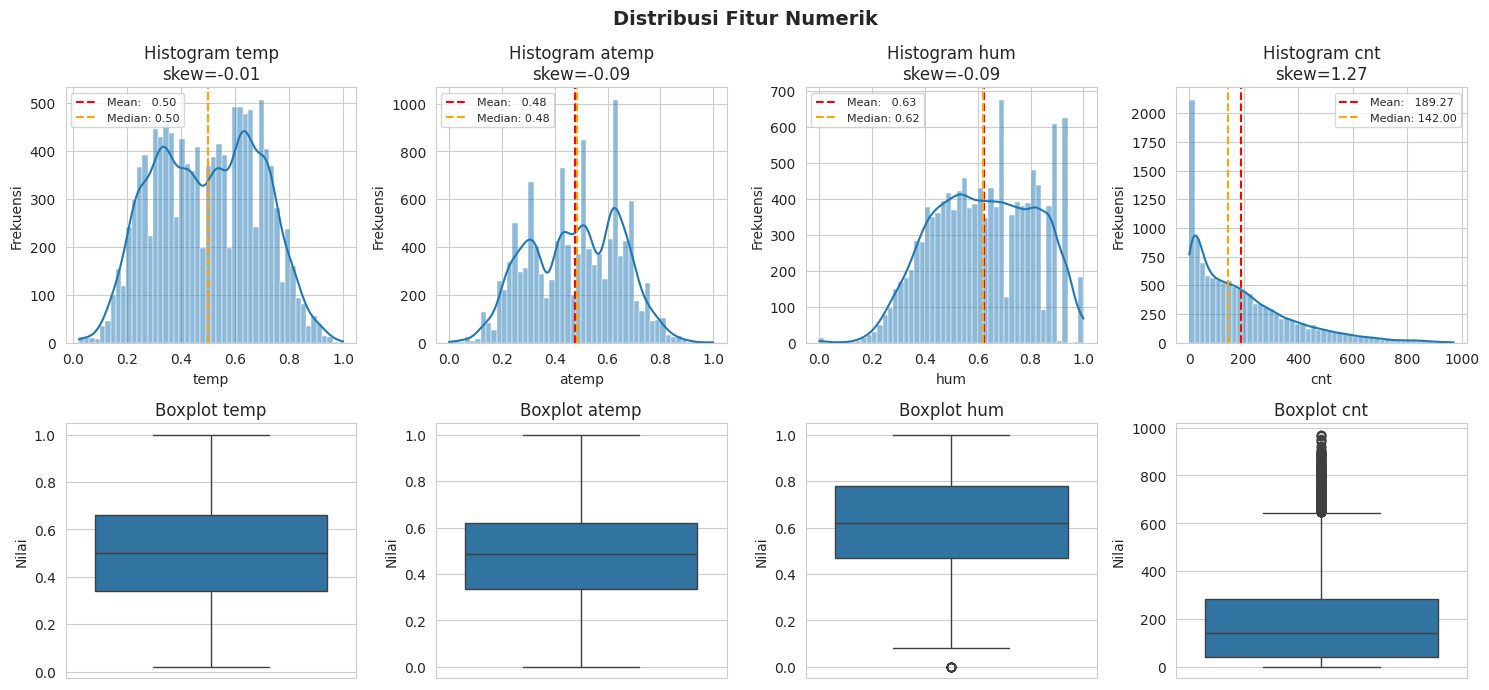

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))

num_cols = ['temp', 'atemp', 'hum', 'cnt']

for i, col in enumerate(num_cols):
  mean_val   = df[col].mean()
  median_val = df[col].median()

  # Baris Atas: Histogram + KDE
  sns.histplot(data=df, x=col, bins=50, kde=True, ax=axes[0, i])
  axes[0, i].axvline(mean_val,   color='red',    linestyle='--', label=f"Mean:   {mean_val:.2f}")
  axes[0, i].axvline(median_val, color='orange', linestyle='--', label=f"Median: {median_val:.2f}")
  axes[0, i].set_title(f"Histogram {col}\nskew={df[col].skew():.2f}")
  axes[0, i].set_xlabel(col)
  axes[0, i].set_ylabel('Frekuensi')
  axes[0, i].legend(fontsize=8)

  # Baris Bawah: Boxplot
  sns.boxplot(data=df, y=col, ax=axes[1, i])
  axes[1, i].set_title(f"Boxplot {col}")
  axes[1, i].set_ylabel('Nilai')

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.1.2 Investigasi Nilai Ekstrem `hum` = 0 (14 data)

In [14]:
# Identifikasi Baris dengan Kelembaban = 0 (Anomali Sensor Deteksi)

hum_zero = df[df['hum'] == 0]

print(f"Jumlah baris dengan hum = 0: {len(hum_zero)} baris")
print(f"Persentase dari total data ({len(df):,}): {len(hum_zero) / len(df) * 100 :.2f}%")
print()
print(hum_zero[['dteday', 'hr', 'hum', 'weathersit', 'temp', 'cnt']].to_string(
      float_format='{:.2f}'.format))


Jumlah baris dengan hum = 0: 14 baris
Persentase dari total data (12,165): 0.12%

           dteday  hr  hum  weathersit  temp  cnt
345    2011-03-10   7 0.00           3  0.38   37
871    2011-03-10  15 0.00           3  0.44   14
1645   2011-03-10   0 0.00           3  0.34    3
3239   2011-03-10  17 0.00           2  0.44  111
3717   2011-03-10  22 0.00           2  0.34   34
4924   2011-03-10   6 0.00           3  0.36   12
7285   2011-03-10   1 0.00           3  0.34    2
7760   2011-03-10  12 0.00           3  0.42   34
8412   2011-03-10   8 0.00           3  0.38   44
8960   2011-03-10  23 0.00           3  0.34   27
9186   2011-03-10  11 0.00           3  0.40   11
9651   2011-03-10   9 0.00           3  0.40   24
10715  2011-03-10  16 0.00           3  0.42   21
11766  2011-03-10  13 0.00           3  0.42   12


## 📊 3.1.3 Interpretasi Distribusi Fitur Numerik

- **`temp` & `atemp`:** Distribusi simetris dan hampir identik -- Mengonfirmasi dugaan multikolinearitas yang akan diverifikasi di analisis multivariat.

- **`hum`:** Mayoritas jam memiliki kelembaban menengah-tinggi. Boxplot menunjukkan adanya outlier mendekati 0 -- Investigasi lebih lanjut mengonfirmasi terdapat **14 baris dengan nilai hum = 0 persis**, seluruhnya berasal dari tanggal yang sama (2011-03-10) dengan weathersit = 3 (hujan ringan). Ini merupakan hal yang mengindikasikan error sensor. Karena jumlahnya sangat kecil (0.12%), baris ini akan di-drop saat preprocessing.

- **`cnt`:** Satu-satunya fitur yang right-skewed signifikan (skewness = 1.27). Mean (189) jauh di atas Median (142) -- Didorong oleh jam-jam peak demand yang membentuk ekor panjang ke kanan. Boxplot juga menunjukkan banyak titik outlier di sisi atas.

## 3.1.4 Distribusi Fitur Kategorikal

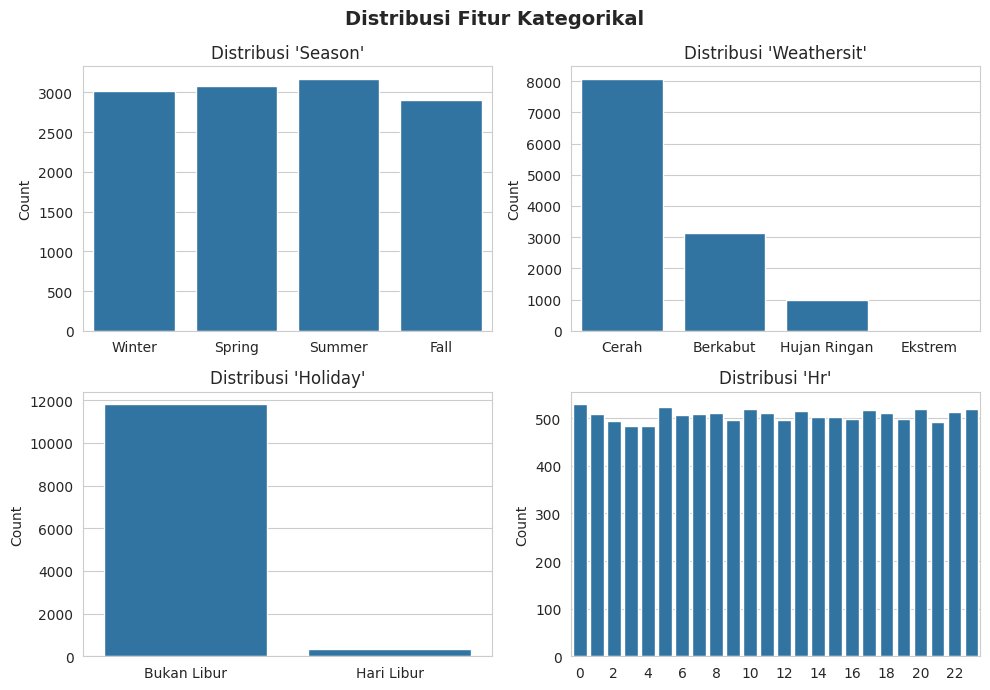

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# Kolom Kategorikal dengan Label Mapping
cat_configs = [
    ('season',     {1:'Winter', 2:'Spring', 3:'Summer', 4:'Fall'},           axes[0, 0], "Distribusi 'Season'"),
    ('weathersit', {1:'Cerah', 2:'Berkabut', 3:'Hujan Ringan', 4:'Ekstrem'}, axes[0, 1], "Distribusi 'Weathersit'"),
    ('holiday',    {0:'Bukan Libur', 1:'Hari Libur'},                        axes[1, 0], "Distribusi 'Holiday'")
]

# Plot Bar untuk Setiap Kolom Kategorikal
for col, mapping, ax, title in cat_configs:
  col_mapped  = df[col].map(mapping)
  order       = list(mapping.values())

  sns.countplot(data=df, x=col_mapped, order=order, ax=ax)
  ax.set_title(title)
  ax.set_xlabel('')
  ax.set_ylabel('Count')

# `hr` Dipisah Karena Tidak Memiliki Label Mapping dan Butuh xticks Khusus
sns.countplot(data=df, x='hr', order=range(24), ax=axes[1, 1])
axes[1, 1].set_title("Distribusi 'Hr'")
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].set_xticklabels(range(0, 24, 2))
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Count')

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 📊 3.1.4.1 Interpretasi Distribusi Fitur Kategorikal

- **`season`:** Distribusi merata di semua musim, tidak ada musim yang mendominasi secara signifikan.

- **`weathersit`:** Sangat tidak merata -- Cuaca cerah jauh mendominasi dibanding kategori lain. Cuaca ekstrem bahkan tidak terlihat di chart karena datanya hanya 3 baris. Ini menjadi limitasi model untuk memprediksi kondisi cuaca ekstrem.

- **`holiday`:** Sangat timpang -- Hari biasa mendominasi secara masif dibanding hari libur.

- **`hr`:** Distribusi sangat merata di semua jam (0-23), artinya setiap jam terwakili dengan baik dalam dataset.


## 3.2 Analisis Bivariat

Melihat hubungan antara setiap fitur dengan target `cnt`.

### 3.2.1 Grouped Analysis: `cnt` per Jam (Weekday vs Weekend)

### 3.2.1.1 Buat Kolom is_weekday (Sementara)

In [16]:
# Persiapan: Ekstrak informasi hari dari `dteday`
# Konversi sementara untuk keperluan analisis EDA
# (Feature Engineering sesungguhnya dilakukan pada tahap preprocessing)

df_eda = df.copy()

df_eda['dteday']     = pd.to_datetime(df_eda['dteday'])
df_eda['is_weekday'] = df_eda['dteday'].dt.dayofweek.apply( # 0=Senin, 1=Selasa, ..., 5=Sabtu, 6=Minggu
    lambda x: 1 if x < 5 else 0
)

print(df_eda['is_weekday'].value_counts())


is_weekday
1    8686
0    3479
Name: count, dtype: int64


### 3.2.1.2 Rata-Rata `cnt` per Jam (Weekday vs Weekend)

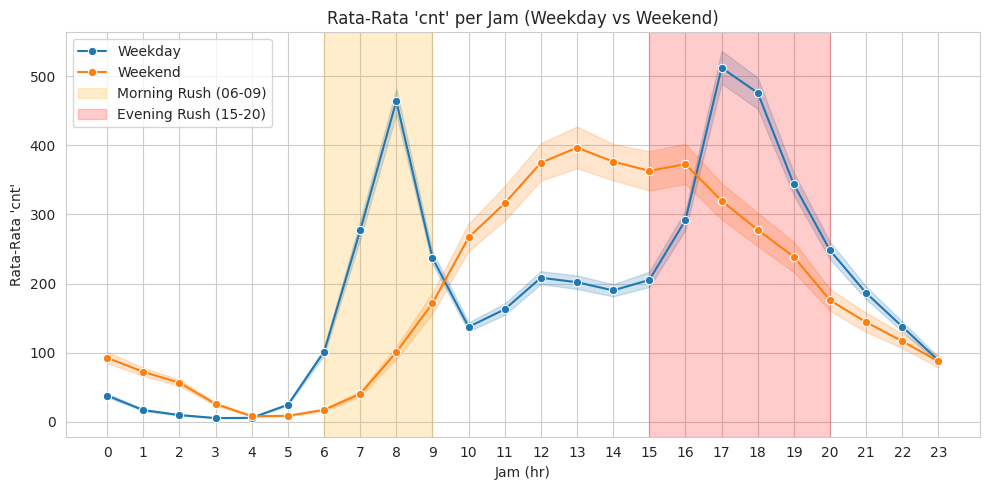

In [17]:
# Map Nilai 0/1 ke Label Readable untuk Legend
df_eda['is_weekday'] = df_eda['is_weekday'].map({0: 'Weekend', 1: 'Weekday'})

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=df_eda, x='hr', y='cnt',
    hue='is_weekday',
    hue_order=['Weekday', 'Weekend'],
    marker='o',
    ax=ax
)

ax.axvspan(6, 9,   alpha=0.2, color='orange', label='Morning Rush (06-09)') # Highlight Rush Hour Pagi
ax.axvspan(15, 20, alpha=0.2, color='red',    label='Evening Rush (15-20)') # Highlight Rush Hour Sore
ax.set_title("Rata-Rata 'cnt' per Jam (Weekday vs Weekend)")
ax.set_xlabel('Jam (hr)')
ax.set_ylabel("Rata-Rata 'cnt'")
ax.set_xticks(range(0, 24))
ax.legend()

plt.tight_layout()
plt.show()


## 📊 3.2.1.3 Interpretasi Rata-Rata cnt per Jam

Plot menunjukkan bahwa weekday dan weekend memiliki karakter **demand yang berbeda**, bukan sekadar berbeda angka.

**Weekday (Hari Kerja):**
- Pola **bimodal tajam** dengan dua puncak yang jelas pada jam 08 dan jam 17.
- Puncak pagi sempit dan curam -- Mencerminkan kemungkinan pola commuter berangkat kerja yang terpusat.
- Puncak sore lebih tinggi dari puncak pagi -- Mencerminkan kemungkinan pola pulang kerja yang sedikit lebih tersebar.
- Demand sangat rendah di luar jam rush hour.
- CI weekday sempit dan konsisten -- Estimasi rata-rata demand per jam stabil, didukung oleh jumlah data weekday yang lebih banyak dari weekend.

**Weekend (Akhir Pekan):**
- Pola **unimodal landai** dengan satu puncak di rentang jam 12-13.
- Tidak ada spike lagi -- Demand naik perlahan mulai jam 06.
- Demand lebih merata sepanjang siang (jam 10-16).
- Dini hari (jam 00-02) justru lebih tinggi dari weekday -- Mencerminkan aktivitas malam di akhir pekan.
- CI weekend lebih lebar terutama di jam 10-20 -- Estimasi rata-rata demand per jam kurang stabil dibanding weekday, kemungkinan kombinasi dari jumlah data weekend yang lebih sedikit dan variasi demand yang lebih tinggi karena aktivitas leisure yang kurang terpola.

**Implikasi untuk modeling:**
- Pola bimodal ini bersifat **non-linear dan tidak monoton** -- Menjadi alasan kuat mengapa tree-based model lebih tepat daripada Linear Regression untuk dataset ini.
- Perbedaan pola weekday vs weekend tidak bisa ditangkap hanya dengan fitur `hr` saja.
- Fitur `is_weekday` wajib dibuat pada tahap feature engineering agar model dapat membedakan kedua karakter demand yang berbeda ini.
- Tanpa fitur ini, model akan "bingung" memprediksi jam 08 karena demand-nya sangat berbeda antara weekday dan weekend.
- CI weekend yang lebih lebar mengindikasikan demand akhir pekan kurang presisi -- Operator perlu membertimbangkan buffer stok yang lebih besar untuk mengantisipasi ketidakpastian ini dibanding hari kerja.
- Dari sisi operasional, jam rush hour adalah periode kritis yang perlu diprioritaskan dalam perencanaan distribusi sepeda.

## 3.2.2 Bar Chart: Fitur Kategorikal vs `cnt`

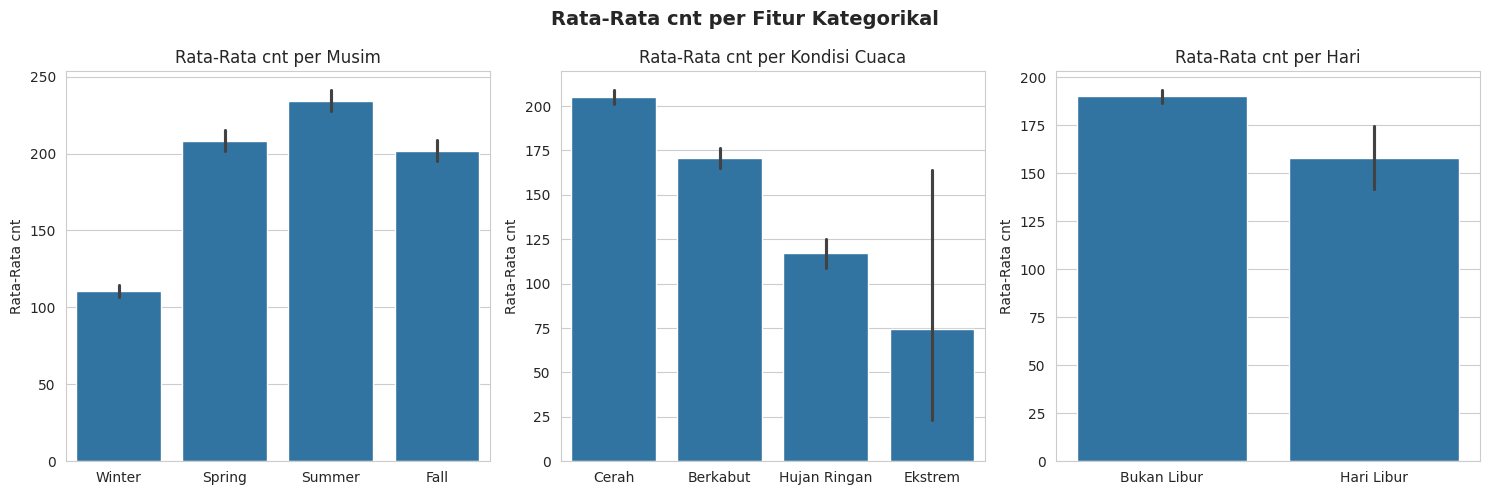

In [18]:
# Rata-Rata cnt per season, weathersit, dan holiday

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

configs = [
    ('season',     {1:'Winter', 2:'Spring', 3:'Summer', 4:'Fall'},           axes[0], "Rata-Rata cnt per Musim"),
    ('weathersit', {1:'Cerah', 2:'Berkabut', 3:'Hujan Ringan', 4:'Ekstrem'}, axes[1], "Rata-Rata cnt per Kondisi Cuaca"),
    ('holiday',    {0:'Bukan Libur', 1:'Hari Libur'},                        axes[2], "Rata-Rata cnt per Hari")
]

# Plot Bar Rata-Rata `cnt` per Kategori
for col, mapping, ax, title in configs:
  col_mapped = df[col].map(mapping)
  order      = list(mapping.values())

  sns.barplot(data=df, x=col_mapped, y='cnt', order=order, ax=ax)
  ax.set_title(title)
  ax.set_xlabel('')
  ax.set_ylabel("Rata-Rata cnt")

plt.suptitle("Rata-Rata cnt per Fitur Kategorikal", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 📊 3.2.2.1 Interpretasi Rata-Rata `cnt` per Fitur Kategorikal

- **Musim:** Winter memiliki rata-rata `cnt` jauh lebih rendah dibanding musim lainnya. Spring, Summer, dan Fall relatif berdekatan dengan Summer sebagai tertinggi -- Menunjukkan cuaca hangat mendorong lebih banyak aktivitas bersepeda. CI semua musim pendek dan konsisten -- Perbedaan antar musim reliable dan bukan kebetulan dari sample.

- **Kondisi Cuaca:** Pola menurun yang konsisten -- Semakin buruk cuaca, semakin rendah rata-rata `cnt`. CI Ekstrem jauh lebih panjang dari kondisi lainnya karena hanya terdiri dari 3 baris data -- Rata-rata demand kondisi Ekstrem tidak representatif dan tidak bisa diandalkan.

- **Hari Libur:** Perbedaannya rata-rata `cnt` antara hari biasa dan hari libur kecil -- Mengindikasikan `holiday` adalah fitur yang relatif lemah pengaruhnya terhadap `cnt`. CI Hari Libur yang lebih lebar dari Bukan Libur mengkonfirmasi estimasi rata-ratanya kurang stabil karena jumlah hari libur jauh lebih sedikit di dataset.

## 3.2.3 Scatter: Fitur Numerik dengan `cnt`

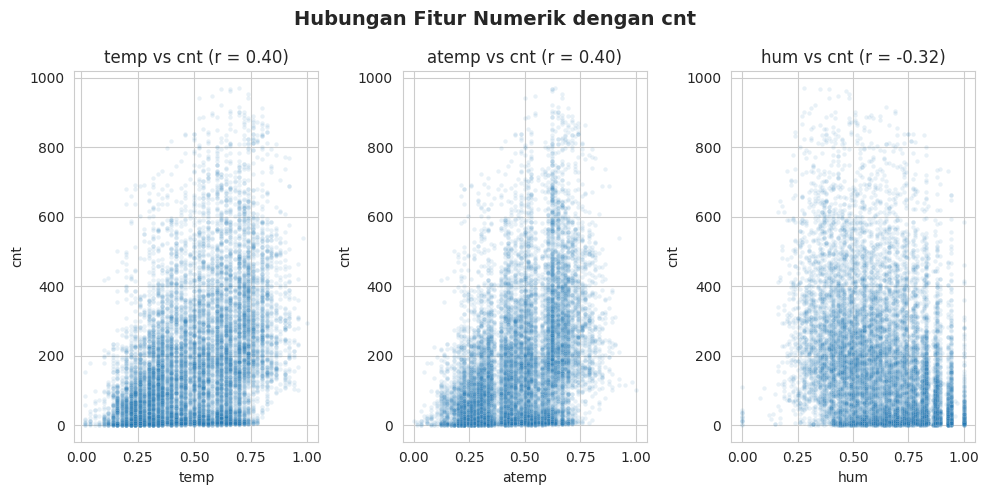

In [19]:
# Scatter Plot: Hubungan temp, atemp, hum vs cnt
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for i, col in enumerate(['temp', 'atemp', 'hum']):
  r_val = df[col].corr(df['cnt']) # Pearson Correlation

  sns.scatterplot(data=df, x=col, y='cnt', alpha=0.1, s=10, ax=axes[i])
  axes[i].set_title(f'{col} vs cnt (r = {r_val:.2f})')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('cnt')

plt.suptitle('Hubungan Fitur Numerik dengan cnt', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 📊 3.2.3.1 Interpretasi Hubungan Fitur Numerik dengan `cnt`

- **`temp` vs `cnt` (r = 0.40):** Terdapat kecenderungan positif -- Suhu lebih tinggi cenderung diikuti demand yang lebih tinggi. Namun scatter yang sangat lebar menunjukkan hubungannya tidak murni linear, banyak faktor lain yang ikut berperan.

- **`atemp` vs `cnt` (r = 0.40):** Pola dan nilai korelasi identik dengan `temp` -- Mengonfirmasi bahwa kedua fitur ini membawa informasi yang hampir sama. Salah satu perlu di-drop di tahap preprocessing untuk menghindari multikolinearitas.

- **`hum` vs `cnt` (r = -0.32):** Kecenderungan negatif -- Kelembaban tinggi cenderung diikuti demand yang lebih rendah. Sebarannya juga sangat lebar -- Hubungannya lemah secara linear dan banyak faktor lain yang ikut berperan.

Tidak ada satu fitur numerik pun yang punya hubungan linear kuat dengan `cnt` -- Memperkuat kebutuhan model yang mampu menangkap pola non-linear dan interaksi antar fitur.

## 3.3 Analisis Multivariat

Melihat hubungan antara beberapa fitur secara bersamaan untuk mendeteksi **multikolinearitas** -- Kondisi di mana dua atau lebih fitur salng berkorelasi tinggi satu sama lain, yang dapat mempengaruhi stabilitas model linear.

## 3.3.1 Heatmap Korelasi Antar Fitur

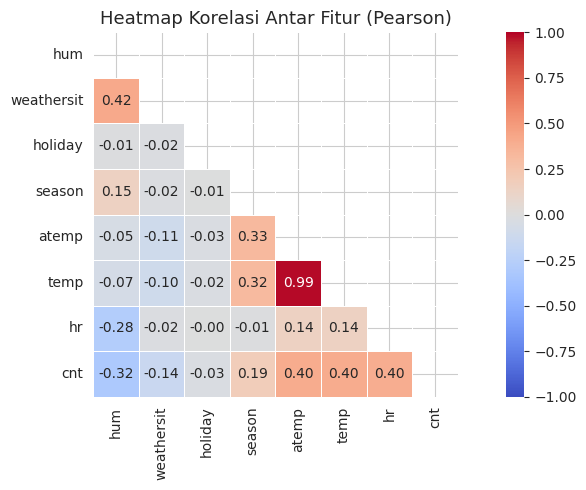

In [20]:
# Heatmap Korelasi -- Drop Kolom Leakage (casual, registered) dan dteday yang Bukan FItur Numerik
corr_df     = df.drop(columns=['casual', 'registered', 'dteday'])
corr_matrix = corr_df.corr()

# Mask Segitiga Atas Agar Heatmap Tidak Menampilkan Nilai Duplikat
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)

ax.set_title('Heatmap Korelasi Antar Fitur (Pearson)', fontsize=13)
plt.tight_layout()
plt.show()


## 📊 3.3.1.1 Interpretasi Heatmap Korelasi Antar Fitur

**`temp` & `atemp` (r = 0.99):**
Korelasi keduanya hampir sempurna -- Keduanya membawa informasi yang hampir identik. Mempertahankan keduanya sekaligus tidak menambah informasi baru bagi model, justru berpotensi mengganggu stabilitas model linear. `temp` dipilih karena merupakan suhu aktual yang lebih objektif dibanding `atemp` yang merupakan *feeling temperature* -- Hasil estimasi persepsi suhu yang tidak bisa diukur secara langsung. `atemp` akan di-drop di tahapp preprocessing.

**Korelasi fitur terhadap target `cnt`:**
- `temp`, `atemp`, `hr` -> Korelasi positif moderat (0.40)
- `hum` -> Korelasi negatif moderat (-0.32)
- `season` -> Korelasi positif lemah (0.19)
- `weathersit` -> Korelasi negatif lemah (-0.14)
- `holiday` -> Hampir tidak berkorelasi (-0.03)

**Catatan**: Korelasi Pearson hanya mengukur hubungan linear. `hr` tercatat 0.40 padahal hubungannya bimodal. Nilai ini tidak sepenuhnya mencerminkan kekuatan hubungan `hr` dengan `cnt` yang sebenarnya.

## 3.3.2 Tren Rata-Rata `cnt` per Bulan (2011-2012)

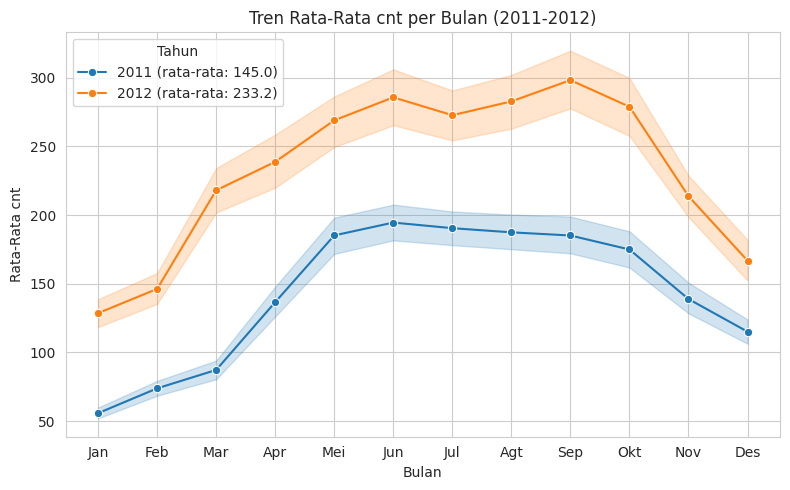

In [21]:
# Ekstrak year dan month dari dteday yang Sudah datetime di Section 3.2.1.1
df_eda['year']  = df_eda['dteday'].dt.year
df_eda['month'] = df_eda['dteday'].dt.month

# Hitung Rata-Rata Tahunan untuk Label Legend
yearly_mean = df_eda.groupby('year')['cnt'].mean().round(1)
df_eda['year_label'] = df_eda['year'].map(
    {y: f'{y} (rata-rata: {yearly_mean[y]:.1f})' for y in yearly_mean.index}
)

fig, ax = plt.subplots(figsize=(8, 5))

# sns.lineplot Menghitung Rata-Rata 'cnt' per Bulan per Tahun Otomatis
sns.lineplot(
    data=df_eda, x='month', y='cnt',
    hue='year_label', marker='o', ax=ax
)
ax.set_title('Tren Rata-Rata cnt per Bulan (2011-2012)', fontsize=12)
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-Rata cnt')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
                    'Jul', 'Agt', 'Sep', 'Okt', 'Nov', 'Des'])
ax.legend(title='Tahun')

plt.tight_layout()
plt.show()


## 📊 3.3.2.1 Interpretasi Tren Rata-Rata cnt per Bulan (2011-2012)

Dua pola terlihat jelas dari chart ini:

- **Seasonality:** Kedua tahun membentuk kurva yang sama -- Demand rendah di awal tahun, naik ke puncak di pertengahan tahun, lalu turun kembali di akhir tahun. Pola ini konsisten dan berulang, mengonfirmasi bahwa informasi temporal dari `dteday` (bulan, musim) adalah fitur yang penting untuk model.

- **Growth Trend:** Rata-rata 2012 (233.2) secara konsisten lebih tinggi dari 2011 (145.0) di semua bulan -- Selisihnya cukup besar dan merata sepanjang tahun. Ini menunjukkan sistem bike-sharing sedang dalam fase pertumbuhan pengguna.

- **CI 2012 lebih lebar dari 2011** -- Terutama di bulan Mei-September, estimasi rata-rata demand 2012 kurang stabil dibanding 2011. Demand yang lebih tinggi di 2012 cenderung lebih bervariasi antar hari -- Kemungkinan karena lebih banyak faktor yang mempengaruhi aktivitas di musim panas seperti cuaca dan event kota.

- **CI kedua tahun tidak overlap di sepanjang tahun** -- Perbedaan demand 2011 vs 2012 genuine dan konsisten di seluruh bulan, bukan kebetulan dari sampel.

Implikasinya terhadap model: Performa prediksi paling akurat untuk kondisi yang serupa dengan periode 2011-2012. Karena demand tumbuh signifikan dari tahun ke tahun, model perlu di-retrain secara berkala dengan data terbaru agar prediksinya tetap relevan seiring bertambahnya jumlah pengguna sistem.

## 3.3.3 Analisis Outlier

In [22]:
# Identifikasi Outlier pada cnt Menggunakan Metode IQR
Q1  = df['cnt'].quantile(0.25)
Q3  = df['cnt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - (1.5 * IQR)) # Di-Clip ke 0 karena `cnt` tidak bisa negatif
upper_bound = Q3 + (1.5 * IQR)

outliers = df[df['cnt'] > upper_bound] # Hanya Cek Sisi Atas Karena lower_bound = 0

print(f"Q1          : {Q1:.0f}")
print(f"Q3          : {Q3:.0f}")
print(f"IQR         : {IQR:.0f}")
print(f"Lower Bound : {lower_bound:.0f}")
print(f"Upper Bound : {upper_bound:.0f}")
print(f"Jumlah Outlier : {len(outliers)} baris ({len(outliers) / len(df) * 100 :.2f}%)")

# Distribusi Outlier Berdasarkan Jam
print("\nOutlier Terbanyak Terjadi Pada Jam:")
print(outliers.groupby('hr').size().sort_values(ascending=False).head(10))

# Distribusi Outlier Berdasarkan Musim
print("\nOutlier Berdasarkan Musim:")
season_map = {1:'Winter', 2:'Spring', 3:'Summer', 4:'Fall'}
print(outliers['season'].map(season_map).value_counts())


Q1          : 40
Q3          : 282
IQR         : 242
Lower Bound : 0
Upper Bound : 645
Jumlah Outlier : 338 baris (2.78%)

Outlier Terbanyak Terjadi Pada Jam:
hr
17    98
8     89
18    84
13    17
14    11
12    11
15    10
16     9
19     8
11     1
dtype: int64

Outlier Berdasarkan Musim:
season
Summer    126
Spring    100
Fall       99
Winter     13
Name: count, dtype: int64


## 📊 3.3.3.1 Interpretasi Analisis Outlier

Menggunakan metode IQR, batas atas outlier berada di **645 penyewaan/jam**. Terdapat **338 baris (2.78%)** yang melewati batas ini -- Seluruhnya di sisi atas, konsisten dengan distribusi `cnt` yang right-skewed.

Outlier terkonsentrasi di:
- **Jam:** 17 (98 baris), 08 (89 baris), 18 (84 baris) -- Persis di window rush hour yang sudah teridentifikasi di analisis bivariat
- **Musim:** Summer (126) dan Spring (100), dan Fall (99) mendominasi secara merata, Winter hanya 13, konsisten dengan pola bahwa outlier terjadi di kondisi cuaca yang mendukung aktivitas bersepeda

Ini mengonfirmasi bahwa outlier bukan error data, melainkan kejadian nyata yang valid. Jam-jam dengan demand sangat tinggi yang terjadi secara konsisten di kondisi tertentu. **Outlier tidak akan dihapus** karena justru merepresentasikan kondisi peak demand yang paling penting untuk diprediksi secara operasional. Menghapusnya akan membuat model kehilangan kemampuan untuk memprediksi situasi tersebut.

## ✅ 3.4 Ringkasan EDA (Exploratory Data Analysis)

Berikut temuan-temuan utama dari seluruh proses EDA yang akan menjadi dasar keputusan di tahap preprocessing dan modeling:

| Temuan | Implikasi |
|---|---|
| Pola `hr` bimodal (puncak jam 08 & 17) | Hubungan non-linear kuat -> Tree-based model lebih cocok |
| `temp` & `atemp` korelasi 0.99 | Drop `atemp` di preprocessing |
| `hum = 0` ada 14 baris | Drop baris tersebut di preprocessing |
| Outlier `cnt` sebanyak 338 baris (2.78%) valid | Tidak dihapus -- Representasi peak demand |
| Pola weekday vs weekend berbeda signifikan | Buat fitur `is_weekday` di feature engineering |
| Seasonality konsisten tiap tahun | Informasi temporal dari `dteday` penting sebagai fitur |
| Growth trend 2011 -> 2012 | Model perlu di-retrain berkala dengan data terbaru |
| `weathersit=4` hanya 3 baris | Limitasi model: Prediksi cuaca ekstrem tidak reliable |

**Langkah selanjutnya:** Data Preprocessing -- Feature engineering, encoding, scaling, dan persiapan data untuk modeling.

# **4. Data Preprocessing**

Berdasarkan temuan di EDA, tahap preprocessing mencakup:
1. **Drop Kolom & Baris** -- Hapus kolom tidak relevan dan 14 baris `hum` = 0
2. **Feature Engineering** -- Ekstraksi fitur temporal dari `dteday` dan cyclical encoding untuk `hr`
3. **Encoding** -- One-Hot Encoding untuk `season`
4. **Train-Test Split (TimeSeriesSplit)** -- Pisahkan data training dan testing
5. **Scaling** -- Normalisasi fitur untuk model linear

## 4.1 Drop Kolom & Baris

Drop kolom tidak relevan (`casual`, `registered`, `atemp`) dan 14 baris `hum = 0` yang kemungkinan teridentifikasi sebagai error sensor deteksi di EDA. Setelah itu data diurutkan berdasarkan waktu (`dteday` + `hr`) agar TimeSeriesSplit bekerja dengan benar pada tahap selanjutnya.

In [23]:
# Salin DataFrame Asli Agar df Original Tidak Berubah
df_clean = df.copy()

# Drop Kolom Target Leakage
df_clean = df_clean.drop(columns=['casual', 'registered'])

# Drop `atemp` karena korelasi 0.99 dengan `temp`
df_clean = df_clean.drop(columns=['atemp'])

# Drop baris dengan hum = 0 -- Nilai Tidak Valid, Humidity tidak mungkin 0% (14 baris)
df_clean = df_clean[df_clean['hum'] != 0].reset_index(drop=True)

# Sort Berdasarkan Waktu (`dteday + hr`) Sebelum Split untuk Menjaga Urutan Temporal
df_clean = df_clean.sort_values(
    ['dteday', 'hr']
).reset_index(drop=True)

print(f"Shape Sebelum : {df.shape[0]:,}, {df.shape[1]}")
print(f"Shape Sesudah : {df_clean.shape[0]:,}, {df_clean.shape[1]}")
print()
print(f"Baris Terhapus : {df.shape[0] - df_clean.shape[0]}")
print(f"Kolom Terhapus : {df.shape[1] - df_clean.shape[1]}")


Shape Sebelum : 12,165, 11
Shape Sesudah : 12,151, 8

Baris Terhapus : 14
Kolom Terhapus : 3


## 4.2 Feature Engineering

Mengekstrak informasi temporal dari kolom `dteday` dan menerapkan cyclical encoding pada `hr`.

In [24]:
# Konversi `dteday` ke datetime untuk Ekstraksi Fitur Temporal
df_clean['dteday'] = pd.to_datetime(df_clean['dteday'])

# Ekstraksi Fitur Temporal dari dteday
df_clean['month']      = df_clean['dteday'].dt.month
df_clean['year']       = df_clean['dteday'].dt.year
df_clean['is_weekday'] = df_clean['dteday'].dt.dayofweek.apply(
    lambda x: 1 if x < 5 else 0)

# Cyclical Encoding untuk `hr` - Agar Model Memahami Jam 23 Dekat dengan Jam 0
df_clean['hr_sin'] = np.sin(2 * np.pi * df_clean['hr'] / 24)
df_clean['hr_cos'] = np.cos(2 * np.pi * df_clean['hr'] / 24)

# Drop Kolom yang Sudah Tidak Diperlukan Setelah Ekstraksi
df_clean = df_clean.drop(columns=['dteday', 'hr'])

print("Kolom Setelah Feature Engineering:")
print(df_clean.columns.tolist())

print(f"\ndf_clean Shape: {df_clean.shape[0]:,}, {df_clean.shape[1]}")

print(f"\nSample Data:")
df_clean.head()


Kolom Setelah Feature Engineering:
['hum', 'weathersit', 'holiday', 'season', 'temp', 'cnt', 'month', 'year', 'is_weekday', 'hr_sin', 'hr_cos']

df_clean Shape: 12,151, 11

Sample Data:


,hum,weathersit,holiday,season,temp,cnt,month,year,is_weekday,hr_sin,hr_cos
0,0.8100,1,0,1,0.2400,16,1,2011,0,0.0000,1.0000
1,0.8000,1,0,1,0.2200,40,1,2011,0,0.2588,0.9659
2,0.8000,1,0,1,0.2200,32,1,2011,0,0.5000,0.8660
3,0.7500,1,0,1,0.2400,13,1,2011,0,0.7071,0.7071
4,0.7500,1,0,1,0.2400,1,1,2011,0,0.8660,0.5000


## 4.3 Encoding

One-Hot Encoding untuk `season` karena bersifat nominal -- Tidak ada urutan yang bermakna antar kategorinya. `weathersit` dibiarkan karena sudah ordinal (1=Cerah -> 4=Ekstrem).

In [25]:
# One-Hot Encoding untuk `season`
# drop_first=True untuk Menghindari Dummy Variable Trap pada Model Linear

df_clean = pd.get_dummies(df_clean, columns=['season'], drop_first=True, dtype=int)

print("Kolom Setelah Encoding:")
print(df_clean.columns.tolist())
print(f"\ndf_clean Shape: {df_clean.shape}")

df_clean.head()


Kolom Setelah Encoding:
['hum', 'weathersit', 'holiday', 'temp', 'cnt', 'month', 'year', 'is_weekday', 'hr_sin', 'hr_cos', 'season_2', 'season_3', 'season_4']

df_clean Shape: (12151, 13)


,hum,weathersit,holiday,temp,cnt,month,year,is_weekday,hr_sin,hr_cos,season_2,season_3,season_4
0,0.8100,1,0,0.2400,16,1,2011,0,0.0000,1.0000,0,0,0
1,0.8000,1,0,0.2200,40,1,2011,0,0.2588,0.9659,0,0,0
2,0.8000,1,0,0.2200,32,1,2011,0,0.5000,0.8660,0,0,0
3,0.7500,1,0,0.2400,13,1,2011,0,0.7071,0.7071,0,0,0
4,0.7500,1,0,0.2400,1,1,2011,0,0.8660,0.5000,0,0,0


## 4.4 Train-Test Split (Temporal Split)

Memisahkan data menjadi training dan testing dengan mempertahankan urutan waktu -- 80% data awal digunakan untuk training dan 20% data akhir untuk testing. Pendekatan ini lebih tepat dibanding pembagian acak karena mencerminkan kondisi nyata: Model dilatih dengan data masa lalu dan dievaluasi pada data yang lebih baru.

Data testing tidak akan disentuh selama proses training dan hanya digunakan untuk evaluasi akhir model.

In [26]:
# Pisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['cnt'])
y = df_clean['cnt']

# Temporal Split: 80% Data Awal (Training), 20% Data Akhir (Testing)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Total Data : {len(df_clean):,}")
print()
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")


Total Data : 12,151

X_train : (9720, 12)
X_test  : (2431, 12)
y_train : (9720,)
y_test  : (2431,)


## 4.5 Scaling

Scaling diterapkan hanya untuk model linear. Untuk tree-based model, scaling tidak diperlukan karena cara kerjanya tidak sensitif terhadap skala fitur.

Scaling dilakukan di dalam **Pipeline** saat tahap modeling -- Bukan di sini -- Untuk menghindari data leakage. Jika scaling dilakukan sebelum train-test split atau pada seluruh data sekaligus, informasi dari data testing akan "bocor" ke proses training.

## ✅ 4.6 Ringkasan Preprocessing

Berikut seluruh transformasi yang telah dilakukan pada data:

| Tahap | Aksi | Hasil |
|---|---|---|
| Drop kolom | `casual`, `registered`, `atemp` | -3 kolom |
| Drop baris | 14 baris `hum = 0` | -14 baris |
| Feature engineering | `dteday` -> `month`, `year`, `is_weekday` | +3 kolom, -1 kolom |
| Cyclical encoding | `hr` -> `hr_sin`, `hr_cos` | +2 kolom, -1 kolom |
| One-Hot encoding | `season` -> `season_2`, `season_3`, `season_4` | +3 kolom, -1 kolom |
| Train-test split | 80% data awal sebagai training (Urutan waktu dipertahankan), 20% data akhir sebagai testing | - |

**Data siap untuk modeling:**
- Shape Final   : 12.151 baris x 12 Fitur
- Training Set  : 9.720 baris
- Testing Set   : 2.431 baris

# **5. Modeling**

Modeling dilakukan secara bertahap -- Mulai dari model sederhana sebagai baseline hingga model ensemble yang lebih kompleks. Setiap model dijalankan menggunakan Pipeline dan dievaluasi dengan metrik yang sama untuk perbandingan yang adil dan konsisten.

**Model yang akan diuji:**
1. Linear Regression <- baseline
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost
6. LightGBM

## ⚙️ Cross-Validation Strategy

In [27]:
# TimeSeriesSplit: Training Selalu dari Data Lama -> Validasi pada Data Baru

tscv = TimeSeriesSplit(n_splits=5)

print(f"CV Strategy : TimeSeriesSplit")
print(f"n_splits    : {tscv.n_splits}")

CV Strategy : TimeSeriesSplit
n_splits    : 5


## 📐 Model Evaluation Function

In [28]:
def evaluate_model(
    model   : Union[Pipeline, BaseEstimator],
    X_train : pd.DataFrame,
    X_test  : pd.DataFrame,
    y_train : pd.Series,
    y_test  : pd.Series,
    cv      = None  # Default None -> Akan Pakai tscv dari Luar
) -> dict:
  """
  Melatih model dan mengevaluasi perfomanya menggunakan TimeSeriesSplit
  cross-validation pada data training dan evaluasi final pada data testing.

  Parameters:
  -----------
  model    : Pipeline / Estimator Sklearn
  X_train  : Fitur Training
  X_test   : Fitur Testing
  y_train  : Target Training
  y_test   : Target Testing
  cv       : CV Strategy (Default: TimeSeriesSplit(n_splits=5))

  Returns:
  --------
  dict berisi hasil metrik evaluasi
  """

  # Gunakan tscv sebagai Default CV Strategy Jika Tidak Dispesifikkan dari Luar
  if cv is None:
    cv = TimeSeriesSplit(n_splits=5)

  # Training & Predict
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  # Cross-Validation RMSE pada Data Training
  cv_scores = cross_val_score(
      model, X_train, y_train,
      scoring='neg_root_mean_squared_error',
      cv=cv, n_jobs=-1
  )
  cv_rmse = -cv_scores.mean() # Dibalik ke Positif Karena Scoring Mengembalikan Nilai Negatif (Higher=Better)
  cv_std  = cv_scores.std()

  # Metrik pada Data Testing
  mae  = mean_absolute_error(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  r2   = r2_score(y_test, y_pred)

  # Print Hasil
  print(f"{'=' * 50}")
  print(f" CV  -> RMSE : {cv_rmse:.2f} ± {cv_std:.2f} (std)")
  print()
  print(f"Test -> RMSE : {rmse:.2f} | MAE : {mae:.2f} | R² : {r2:.4f}")
  print(f"{'=' * 50}")

  return {
      'model'  : model,
      'mae'    : mae,
      'rmse'   : rmse,
      'r2'     : r2,
      'cv_rmse': cv_rmse,
      'cv_std' : cv_std
  }

## 5.0 Naive Baseline

Sebelum melatih model apapun, kita perlu menetapkan **batas minimum performa** yang harus dilampaui. Naive Baseline adalah pendekatan prediksi paling sederhana yang bisa dibuat -- Setiap jam diprediksi memiliki demand yang sama dengan rata-rata historis training data (175.16 sepeda/jam), tanpa mempertimbangkan fitur temporal, cuaca, maupun karakteristik hari operasional.

Jika model ML yang dibangun tidak bisa mengalahkan prediksi sederhana ini, model tersebut tidak memberikan nilai tambah apapun dibanding pendekatan tanpa model. Hasil Naive Baseline menjadi **patokan bawah** untuk evaluasi semua model selanjutnya.

In [29]:
# Buat Array Prediksi Konstan Sebesar Rata-Rata Demand Training untuk Seluruh Test Set
naive_pred_test  = np.full(len(y_test), y_train.mean())

# Evaluasi Metrik Naive Baseline pada Data Testing
naive_mae  = mean_absolute_error(y_test, naive_pred_test)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred_test))
naive_r2   = r2_score(y_test, naive_pred_test)

print('=' * 40)
print("Naive Baseline (Mean Predictor)")
print('=' * 40)
print(f"Mean Training Demand : {y_train.mean():.2f} sepeda/jam")
print(f"RMSE                 : {naive_rmse:.2f}")
print(f"MAE                  : {naive_mae:.2f}")
print(f"R²                   : {naive_r2:.4f}")
print('=' * 40)
print()
print("===================== Target Goals ======================")
print(f"Target RMSE (< 50% LR) : Dievaluasi setelah LR dijalankan")
print(f"Target MAE  (≤ 50%)    : {naive_mae * 0.5:.2f} sepeda")
print(f"Target R²   (> 0.85)   : 0.8500")

Naive Baseline (Mean Predictor)
Mean Training Demand : 175.16 sepeda/jam
RMSE                 : 231.73
MAE                  : 175.27
R²                   : -0.1052

===================== Target Goals ======================
Target RMSE (< 50% LR) : Dievaluasi setelah LR dijalankan
Target MAE  (≤ 50%)    : 87.63 sepeda
Target R²   (> 0.85)   : 0.8500


## 📊 5.0.1 Interpretasi Naive Baseline

Naive baseline menghasilkan MAE 175.27 dan RMSE 231.73 -- Kedua angka yang sangat besar karena model ini memprediksi nilai yang sama (175 sepeda/jam) untuk setiap jam tanpa mempertimbangkan kondisi temporal, cuaca, maupun karakteristik hari operasional.

R² sebesar -0.1052 mengonfirmasi bahwa naive baseline bahkan lebih buruk dari sekedar memprediksi rata-rata test set itu sendiri. Ini terjadi karena mean training (175 sepeda/jam) tidak lagi representatif untuk test set -- Demand di periode akhir 2012 sudah tumbuh lebih tinggi akibat pertumbuhan pengguna Capital Bikeshare, sehingga prediksi 175 secara sistematis meleset ke bawah untuk seluruh test period. Ini adalah konsekuensi yang expected dari temporal split pada data dengan growth trend, dan justru mengonfirmasi bahwa pendekatan tanpa model tidak bisa diandalkan untuk operasional.

Angka-angka ini menjadi patokan batas bawah yang harus dilampaui secara signifikan oleh model ML, sesuai target yang ditetapkan di Goals:
- Target MAE ≤ 87.63 sepeda (50% dari 175.27)
- Target RMSE < 82.07 sepeda (50% dari LR baseline, dievaluasi setelah section 5.1)
- Target R² > 0.85

## 5.1 Benchmark Model (Default Parameter)

## 5.1.1 Linear Regression

Linear Regression digunakan sebagai baseline -- Model paling sederhana yang menjadi patokan minimum. Semua model selanjutnya harus menghasilkan performa yang lebih baik dari ini.

In [30]:
# Pipeline: StandardScaler + Linear Regression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

print("Linear Regression:")
lr_result = evaluate_model(lr_pipeline, X_train, X_test, y_train, y_test)


Linear Regression:
 CV  -> RMSE : 131.18 ± 21.23 (std)

Test -> RMSE : 164.13 | MAE : 122.77 | R² : 0.4455


## 5.1.2 Decision Tree

Decision Tree digunakan sebagai stepping stone menuju ensemble model. Model ini tidak memerlukan scaling karena cara kerjanya berbasis treshold, bukan jarak antar nilai.

In [31]:
# Pipeline: Decision Tree (tanpa scaling)

dt_pipeline = Pipeline([
    ('model', DecisionTreeRegressor(random_state=42))
])

print("Decision Tree:")
dt_result = evaluate_model(dt_pipeline, X_train, X_test, y_train, y_test)


Decision Tree:
 CV  -> RMSE : 93.29 ± 15.67 (std)

Test -> RMSE : 94.91 | MAE : 62.19 | R² : 0.8146


## 5.1.3 Random Forest

Random Forest membangun banyak Decision Tree secara paralel pada subset data dan fitur yang berbeda-beda, lalu merata-ratakan hasilnya. Pendekatan ini mengurangi overfitting yang menjadi kelemahan Decision Tree tunggal.

In [32]:
# Pipeline: Random Forest (tanpa scaling)

rf_pipeline = Pipeline([
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

print("Random Forest:")
rf_result = evaluate_model(rf_pipeline, X_train, X_test, y_train, y_test)


Random Forest:
 CV  -> RMSE : 79.81 ± 17.00 (std)

Test -> RMSE : 79.14 | MAE : 52.70 | R² : 0.8711


## 5.1.4 Gradient Boosting

Berbeda dengan Random Forest yang membangun tree secara paralel, Gradient Boosting membangun tree secara **sequential** -- Setiap tree baru berfokus memperbaiki error yang dibuat tree sebelumnya.

In [33]:
# Pipeline: Gradient Boosting (tanpa scaling)

gb_pipeline = Pipeline([
    ('model', GradientBoostingRegressor(random_state=42))
])

print("Gradient Boosting:")
gb_result = evaluate_model(gb_pipeline, X_train, X_test, y_train, y_test)


Gradient Boosting:
 CV  -> RMSE : 87.50 ± 15.83 (std)

Test -> RMSE : 102.80 | MAE : 71.94 | R² : 0.7825


## 5.1.5 XGBoost

XGBoost adalah implementasi Gradient Boosting yang dioptimalkan -- Lebih cepat, lebih efisien secara memori, dan umumnya menghasilkan performa lebih baik dibanding Gradient Boosting standar dengan regularisasi bawaan yang mencegah overfitting.

In [34]:
# Pipeline: XGBoost (tanpa scaling)

xgb_pipeline = Pipeline ([
    ('model', XGBRegressor(random_state=42, n_jobs=-1))
])

print("XGBoost:")
xgb_result = evaluate_model(xgb_pipeline, X_train, X_test, y_train, y_test)


XGBoost:
 CV  -> RMSE : 74.82 ± 12.68 (std)

Test -> RMSE : 71.76 | MAE : 48.59 | R² : 0.8940


## 5.1.6 LightGBM

LightGBM adalah implementasi Gradient Boosting dengan pendekatan leaf-wise tree-growth, tree tumbuh dengan memprioritaskan leaf yang memiliki loss terbesar, berbeda dengan XGBoost yang tumbuh secara level-wise. Pendekatan ini umumnya menghasilkan akurasi lebih tinggi dengan waktu training lebih cepat, namun lebih rentan overfit jika tidak dikontrol dengan baik.

In [35]:
# Pipeline: LightGBM (tanpa scaling)

lgbm_pipeline = Pipeline([
    ('model', LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

print("LightGBM:")
lgbm_result = evaluate_model(lgbm_pipeline, X_train, X_test, y_train, y_test)


LightGBM:
 CV  -> RMSE : 74.43 ± 13.58 (std)

Test -> RMSE : 66.87 | MAE : 45.30 | R² : 0.9080


## 5.2 Perbandingan Model

Membandingkan performa seluruh model berdasarkan metrik evaluasi yang sama untuk menentukan kandidat terbaik yang akan masuk ke tahap hyperparameter tuning.

In [36]:
# Kumpulkan Semua Hasil Model ke Dalam Satu Dict
results = {
    'Linear Regression' : lr_result,
    'Decision Tree'     : dt_result,
    'Random Forest'     : rf_result,
    'Gradient Boosting' : gb_result,
    'XGBoost'           : xgb_result,
    'LightGBM'          : lgbm_result
}

# Buat DataFrame Perbandingan dari Semua Hasil Model
comparison_df = pd.DataFrame({
    name: {
        'CV RMSE'  : result['cv_rmse'],
        'CV Std'   : result['cv_std'],
        'RMSE'     : result['rmse'],
        'MAE'      : result['mae'],
        'R²'       : result['r2'],
    }
    for name, result in results.items()
}).T

# Sort Berdasarkan RMSE Saat Masih Numerik
comparison_df = comparison_df.sort_values('RMSE')

# Format Desimal per Kolom
for col in ['CV RMSE', 'CV Std', 'RMSE', 'MAE']:
  comparison_df[col] = comparison_df[col].round(2).map('{:.2f}'.format)
comparison_df['R²'] = comparison_df['R²'].round(4).map('{:.4f}'.format)

print("Perbandingan Semua Model:")
print(f"{'=' * 56}")
print(comparison_df)


Perbandingan Semua Model:
                  CV RMSE CV Std    RMSE     MAE      R²
LightGBM            74.43  13.58   66.87   45.30  0.9080
XGBoost             74.82  12.68   71.76   48.59  0.8940
Random Forest       79.81  17.00   79.14   52.70  0.8711
Decision Tree       93.29  15.67   94.91   62.19  0.8146
Gradient Boosting   87.50  15.83  102.80   71.94  0.7825
Linear Regression  131.18  21.23  164.13  122.77  0.4455


## 📊 5.2.1 Interpretasi Perbandingan Model

Berdasarkan metrik RMSE sebagai metrik utama:

| Ranking | Model | CV RMSE | CV Std | RMSE Test |
|---|---|---|---|---|
| 1 | LightGBM | 74.43 | 13.58 | 66.87 |
| 2 | XGBoost | 74.82 | 12.68 | 71.76 |
| 3 | Random Forest | 79.81 | 17.00 | 79.14 |
| 4 | Decision Tree | 93.29 | 15.67 | 94.91 |
| 5 | Gradient Boosting | 87.50 | 15.83 | 102.80 |
| 6 | Linear Regression | 131.18 | 21.23 | 164.13 |

**Temuan Utama:**

- **LightGBM, dan XGBoost** mendominasi peringkat teratas dengan CV RMSE yang hampir identik. XGBoost sedikit lebih konsisten (CV Std 12.68 vs 13.58), namun LightGBM unggul di RMSE Test Set (66.87 vs 71.76).

- **Gradient Boosting** performanya jauh di bawah ekspektasi dengan parameter default, bahkan kalah dari Decision Tree tunggal -- Mengonfirmasi bahwa Gradient Boosting sangat sensitif terhadap hyperparameter.

- **Linear Regression** jauh tertinggal dengan CV Std terbesar (21.23) -- Mengonfirmasi temuan EDA bahwa pola data ini non-linear dan tidak cocok untuk model linear.

**Keputusan:** LightGBM, XGBoost, dan Random Forest akan dibawa ke tahap hyperparameter tuning.

## 5.3 Hyperparameter Tuning

Tiga model terbaik dari hasil benchmark -- LightGBM, XGBoost, dan Random Forest -- Akan di-tuning untuk memaksimalkan performanya. Metode search dipilih berdasarkan kompleksitas ruang parameter dan karakteristik masing-masing model:

| Model | Metode | Alasan |
|---|---|---|
| Random Forest | RandomizedSearchCV | Ruang parameter luas -- Random Search lebih efisien dari Grid Search dengan hasil yang sebanding |
| XGBoost & LightGBM | RandomizedSearchCV -> BayesSearchCV | Fase 1 untuk eksplorasi lebar, Fase 2 untuk fine-tuning di area terbaik hasil Fase 1 |

## ⏱️ Hyperparameter Search Function

In [37]:
def run_search(
    search_obj : Union[RandomizedSearchCV, BayesSearchCV],
    X_train    : pd.DataFrame,
    y_train    : pd.Series,
    name       : str = ""
) -> Union[RandomizedSearchCV, BayesSearchCV]:
  """
  Menjalankan hyperparameter search dan menampilkan hasilnya.

  Parameters:
  -----------
  search_obj : Object Search untuk Hyperparameter Tuning
  X_train : Fitur Training
  y_train : Target Training
  name : Nama Model untuk Display

  Returns:
  --------
  search_obj yang sudah di-fit
  """

  # Catat Waktu Eksekusi
  start = time.time()
  search_obj.fit(X_train, y_train)
  elapsed = time.time() - start

  # Tampilkan Hasil Terbaik
  print(f"{name}")
  print(f"{'=' * 45}")
  print(f"Best CV RMSE: {-search_obj.best_score_:.2f}")
  print(f"\nBest Params:")
  for k, v in search_obj.best_params_.items():
    print(f"   {k}: {v}")
  print(f"{'=' * 45}")
  print(f"Waktu : {elapsed:.1f} detik ({elapsed / 60 :.1f} menit)")

  return search_obj

## 5.3.1 Random Forest Tuning

Parameter:

**`n_estimators`:** Jumlah Decision Tree yang dibangun secara paralel. Semakin banyak tree, prediksi semakin stabil karena hasil akhir adalah rata-rata dari semua tree.

**`max_depth`:** Kedalaman maksimum setiap tree -- Seberapa banyak "pertanyaan" bertingkat yang bisa dibuat. Depth lebih dalam memungkinkan model menangkap interaksi antar fitur yang lebih kompleks.

**`min_samples_split`:** Minimum jumlah sample di sebuah node sebelum boleh di-split. Nilai lebih besar membuat tree lebih konservatif dan mengurangi risiko split yang tidak bermakna.

**`min_samples_leaf`:** Minimum jumlah sample yang harus ada di setiap leaf. Mengontrol seberapa spesifik prediksi di setiap ujung tree -- Nilai kecil memungkinkan model menangkap pola yang lebih detail.

**`max_features`:** Proporsi fitur yang dipertimbangkan saat mencari split terbaik di setiap node. Nilai tertinggi diperlukan ketika fitur-fitur memiliki interaksi kuat satu sama lain.

In [44]:
# Ruang Parameter Random Forest
rf_param_dist = {
    'model__n_estimators'      : randint(100, 1000), # Default: 100
    'model__max_depth'         : randint(10, 20),    # Default: None (Tidak Terbatas)
    'model__min_samples_split' : randint(2, 10),     # Default: 2    (Min. Sample untuk Split)
    'model__min_samples_leaf'  : randint(1, 5),      # Default: 1    (Min. Sample per Leaf)
    'model__max_features'      : uniform(0.5, 0.4)   # Default: 1.0  (Pakai Semua Fitur)
}

# RandomizedSearchCV (TimeSeriesSplit)
rf_random = RandomizedSearchCV(
    estimator           = rf_pipeline,
    param_distributions = rf_param_dist,
    n_iter              = 70,
    scoring             = 'neg_root_mean_squared_error',
    cv                  = tscv,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 0
)

rf_random = run_search(rf_random, X_train, y_train, "Random Forest Tuning")


Random Forest Tuning
Best CV RMSE: 78.47

Best Params:
   model__max_depth: 14
   model__max_features: 0.7347004662655393
   model__min_samples_leaf: 1
   model__min_samples_split: 5
   model__n_estimators: 287
Waktu : 1595.4 detik (26.6 menit)


## 5.3.1.1 Evaluasi Random Forest Setelah Tuning

In [45]:
# Evaluasi Best Estimator Hasil Tuning pada Test Set
print("Random Forest (Tuned):")
rf_tuned_result = evaluate_model(
    rf_random.best_estimator_,
    X_train, X_test, y_train, y_test
)

# Perbandingan RMSE Sebelum dan Sesudah Tuning
print(f"RF Default RMSE : {rf_result['rmse']:.2f}")
print(f"RF Tuned RMSE   : {rf_tuned_result['rmse']:.2f}")


Random Forest (Tuned):
 CV  -> RMSE : 78.47 ± 16.96 (std)

Test -> RMSE : 78.42 | MAE : 52.07 | R² : 0.8734
RF Default RMSE : 79.14
RF Tuned RMSE   : 78.42


## 5.3.2 XGBoost Tuning

XGBoost di-tuning dalam dua fase:

- **Fase 1:** RandomizedSearchCV untuk eksplorasi lebar dan menemukan area parameter yang potensial.
- **Fase 2:** BayesSearchCV dengan ruang yang dipersempit berdasarkan hasil Fase 1 untuk fine-tuning lebih presisi.

Parameter:

**`n_estimators`:** Jumlah tree yang dibangun secara berurutan, di mana setiap tree memperbaiki error tree sebelumnya. Semakin banyak tree dengan learning rate rendah menghasilkan prediksi yang lebih presisi.

**`max_depth`:** Kedalaman maksimum setiap tree. Untuk boosting, tree dangkal (3-6) umumnya lebih baik karena banyak tree dangkal lebih efektif dari sedikit tree dalam.

**`learning_rate`:** Seberapa besar kontribusi setiap tree baru terhadap prediksi akhir. Learning rate kecil dengan banyak tree menghasilkan model yang lebih akurat dan stabil.

**`subsample`:** Proporsi data training yang dipakai untuk setiap tree. Nilai di bawah 1.0 membuat tree belajar dari sudut pandang data yang berbeda, mengurangi overfitting.

**`colsample_bytree`:** Proporsi fitur yang dipakai untuk setiap tree. Membatasi jumlah fitur membuat tree lebih beragam dan model lebih robust.

**`min_child_weight`:** Minimum jumlah tree sample yang dibutuhkan di sebuah leaf sebelum tree berhenti split. Nilai lebih besar membuat model lebih konservatif dan mengurangi overfitting.

**`gamma`:** Minimum pengurangan error yang dibutuhkan untuk melakukan split baru. Semakin besar gamma, semakin selektif tree dalam membuat split -- Hanya split yang benar-benar berguna yang diizinkan.

**`reg_alpha`:** Regularisasi L1 yang mendorong bobot leaf yang tidak penting menjadi 0. Membantu model fokus pada fitur dan pola yang benar-benar bermakna.

**`reg_lambda`:** Regularisasi L2 yang mendorong semua bobot tetap kecil tanpa menghilangkannya. Membuat model lebih stabil dan mencegah bobot ekstrem yang bisa menyebabkan overfitting.

## 5.3.2.1 XGBoost Tuning Fase 1 (Random Search)

In [46]:
# Ruang Parameter XGBoost - Fase 1 (Eksplorasi Lebar)
xgb_param_dist = {
    'model__n_estimators'     : randint(100, 1000),    # Default: 100
    'model__max_depth'        : randint(3, 10),        # Default: 6
    'model__learning_rate'    : loguniform(0.01, 0.3), # Default: 0.3
    'model__subsample'        : uniform(0.5, 0.5),     # Default: 1.0 (Pakai Semua Data)
    'model__colsample_bytree' : uniform(0.5, 0.5),     # Default: 1.0 (Pakai Semua Fitur)
    'model__min_child_weight' : randint(1, 10),        # Default: 1
    'model__gamma'            : uniform(0, 0.3),       # Default: 0 (Minimum Loss Reduction per Split)
    'model__reg_alpha'        : uniform(0, 0.5),       # Default: 0 (Tidak ada L1)
    'model__reg_lambda'       : uniform(0.0, 2.0)      # Default: 1 (L2 Regularization)
}

# RandomizedSearchCV - Fase 1 (TimeSeriesSplit)
xgb_random              = RandomizedSearchCV(
    estimator           = xgb_pipeline,
    param_distributions = xgb_param_dist,
    n_iter              = 100,
    scoring             = 'neg_root_mean_squared_error',
    cv                  = tscv,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 0
)

xgb_random = run_search(xgb_random, X_train, y_train, "XGBoost Tuning - Fase 1 (Random Search)")


XGBoost Tuning - Fase 1 (Random Search)
Best CV RMSE: 70.27

Best Params:
   model__colsample_bytree: 0.953933065231258
   model__gamma: 0.09485897468894838
   model__learning_rate: 0.07396057776325353
   model__max_depth: 4
   model__min_child_weight: 8
   model__n_estimators: 939
   model__reg_alpha: 0.2195674542851092
   model__reg_lambda: 0.7538888588498152
   model__subsample: 0.7313398928348032
Waktu : 247.9 detik (4.1 menit)


## 5.3.2.2 Evaluasi XGBoost Setelah Fase 1 (Random Search)

In [47]:
# Evaluasi Best Estimator Fase 1 pada Test Set
print("XGBoost (Fase 1 - Random Search):")
xgb_phase1_result = evaluate_model(
    xgb_random.best_estimator_,
    X_train, X_test, y_train, y_test
)

# Perbandingan XGBoost Default vs Fase 1
print(f"XGBoost Default RMSE : {xgb_result['rmse']:.2f}")
print(f"XGBoost Fase 1 RMSE  : {xgb_phase1_result['rmse']:.2f}")


XGBoost (Fase 1 - Random Search):
 CV  -> RMSE : 70.27 ± 10.28 (std)

Test -> RMSE : 68.31 | MAE : 46.56 | R² : 0.9040
XGBoost Default RMSE : 71.76
XGBoost Fase 1 RMSE  : 68.31


## 5.3.2.3 XGBoost Tuning Fase 2 (Bayes Search)

In [48]:
# Ruang Parameter XGBoost - Fase 2
# Disesuaikan Berdasarkan Arah Optimal Fase 1
xgb_param_bayes = {
    'model__n_estimators'     : Integer(1300, 1700), # Default: 100
    'model__max_depth'        : Integer(3, 5),       # Default: 6
    'model__learning_rate'    : Real(0.04, 0.06),    # Default: 0.3
    'model__subsample'        : Real(0.55, 0.65),    # Default: 1.0 (Pakai Semua Data)
    'model__colsample_bytree' : Real(0.70, 0.90),    # Default: 1.0 (Pakai Semua Fitur)
    'model__min_child_weight' : Integer(5, 7),       # Default: 1
    'model__gamma'            : Real(0.06, 0.08),    # Default: 0   (Minimum Loss Reduction per Split)
    'model__reg_alpha'        : Real(0.13, 0.17),    # Default: 0   (Tidak Ada L1)
    'model__reg_lambda'       : Real(0.75, 0.95)     # Default: 1.0 (L2 Regularization)
}

# BayesSearchCV - Fase 2
xgb_bayes         = BayesSearchCV(
    estimator     = xgb_pipeline,
    search_spaces = xgb_param_bayes,
    n_iter        = 50,
    scoring       = 'neg_root_mean_squared_error',
    cv            = tscv,
    random_state  = 42,
    n_jobs        = -1,
    verbose       = 0
)

xgb_best = run_search(xgb_bayes, X_train, y_train, "XGBoost Tuning - Fase 2 (Bayes Search)")


XGBoost Tuning - Fase 2 (Bayes Search)
Best CV RMSE: 69.11

Best Params:
   model__colsample_bytree: 0.8311824303867404
   model__gamma: 0.07697470284436454
   model__learning_rate: 0.04730654428520831
   model__max_depth: 4
   model__min_child_weight: 6
   model__n_estimators: 1700
   model__reg_alpha: 0.16210804904882953
   model__reg_lambda: 0.95
   model__subsample: 0.5802625454843489
Waktu : 322.2 detik (5.4 menit)


## 5.3.2.4 Evaluasi XGBoost Setelah Tuning

In [49]:
# Evaluasi Best Estimator Hasil Tuning pada Test Set
print("XGBoost (Tuned):")
xgb_tuned_result = evaluate_model(
    xgb_best.best_estimator_,
    X_train, X_test, y_train, y_test
)

# Perbandingan XGBoost Default vs Fase 1 vs Tuned
print(f"XGBoost Default RMSE : {xgb_result['rmse']:.2f}")
print(f"XGBoost Fase 1 RMSE  : {xgb_phase1_result['rmse']:.2f}")
print(f"XGBoost Tuned RMSE   : {xgb_tuned_result['rmse']:.2f}")


XGBoost (Tuned):
 CV  -> RMSE : 69.11 ± 9.17 (std)

Test -> RMSE : 67.88 | MAE : 46.17 | R² : 0.9052
XGBoost Default RMSE : 71.76
XGBoost Fase 1 RMSE  : 68.31
XGBoost Tuned RMSE   : 67.88


## 5.3.3 LightGBM Tuning

LightGBM di-tuning dalam dua fase:

- **Fase 1:** RandomizedSearchCV untuk eksplorasi lebar dan menemukan area parameter yang potensial.
- **Fase 2:** BayesSearchCV dengan ruang yang dipersempit berdasarkan hasil Fase 1 untuk fine-tuning lebih presisi.

Parameter:

**`n_estimators`:** Jumlah tree yang dibangun secara berurutan. Semakin banyak tree dengan learning rate rendah menghasilkan prediksi yang lebih presisi.

**`num_leaves`:** Parameter utama LightGBM yang mengontrol kompleksitas tree -- Berbeda dari max_depth, LightGBM tumbuh leaf-wise dengan memprioritaskan leaf yang memiliki loss terbesar, menghasilkan tree yang lebih efisien.

**`learning_rate`:** Seberapa besar kontribusi setiap tree baru. Learning rate kecil dengan banyak tree menghasilkan model yang lebih akurat dan stabil.

**`subsample`:** Proporsi data training yang dipakai untuk setiap tree. Harus dikombinasikan dengan subsample_freq > 0 agar benar-benar aktif di LightGBM.

**`subsample_freq`:** Seberapa sering subsample dilakukan -- Nilai 0 (Default) menonaktifkan subsample sepenuhnya. Harus diset > 0 agar parameter subsample bekerja.

**`colsample_bytree`:** Proporsi fitur yang dipakai untuk setiap tree. Membatasi fitur membuat tree lebih beragam dan model lebih robust.

**`min_child_samples`:** Minimum jumlah data yang harus ada di setiap leaf. Nilai lebih besar membuat model lebih konservatif dan stabil di berbagai kondisi data.

**`reg_alpha`:** Regularisasi L1 yang mendorong bobot leaf tidak penting menuju nol. Default LightGBM adalah 0 -- Tidak ada L1 Regularization secara bawaan.

**`reg_lambda`:** Regularisasi L2 yang mendorong semua bobot tetap kecil. Berbeda dari XGBoost, default LightGBM adalah 0 sehingga perlu diset manual untuk stabilitas model.

**`min_split_gain`:** Minimum pengurangan loss yang dibutuhkan untuk melakukan split baru -- Setara gamma di XGBoost. Mencegah model belajar dari noise yang tidak bermakna.

## 5.3.3.1 LightGBM Tuning Fase 1 (Random Search)

In [40]:
# Ruang Parameter LightGBM - Fase 1 (Eksplorasi Lebar)
lgbm_param_dist = {
    'model__n_estimators'      : randint(100, 1000),     # Default: 100
    'model__num_leaves'        : randint(10, 150),       # Default: 31
    'model__learning_rate'     : loguniform(0.01, 0.30), # Default: 0.1
    'model__subsample'         : uniform(0.5, 0.5),      # Default: 1.0 (Pakai Semua Data)
    'model__subsample_freq'    : randint(1, 10),         # Default: 0   (Subsample Tidak Aktif)
    'model__colsample_bytree'  : uniform(0.5, 0.5),      # Default: 1.0 (Pakai Semua Fitur)
    'model__min_child_samples' : randint(5, 50),         # Default: 20
    'model__reg_alpha'         : uniform(0, 0.5),        # Default: 0.0 (Tidak Ada L1)
    'model__reg_lambda'        : uniform(0, 1.0),        # Default: 0.0 (Tidak Ada L2)
    'model__min_split_gain'    : uniform(0, 0.3)         # Default: 0   (Minimum Loss Reduction per Split)
}

# RandomizedSearchCV - Fase 1 (TimeSeriesSplit)
lgbm_random             = RandomizedSearchCV(
    estimator           = lgbm_pipeline,
    param_distributions = lgbm_param_dist,
    n_iter              = 75,
    scoring             = 'neg_root_mean_squared_error',
    cv                  = tscv,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 0
)

lgbm_random = run_search(lgbm_random, X_train, y_train, "LightGBM Tuning - Fase 1 (Random Search)")


LightGBM Tuning - Fase 1 (Random Search)
Best CV RMSE: 70.92

Best Params:
   model__colsample_bytree: 0.8067075979678949
   model__learning_rate: 0.04147588661423153
   model__min_child_samples: 34
   model__min_split_gain: 0.2598191668501225
   model__n_estimators: 976
   model__num_leaves: 14
   model__reg_alpha: 0.013183487248626002
   model__reg_lambda: 0.3764633668780496
   model__subsample: 0.9052766653909164
   model__subsample_freq: 1
Waktu : 946.8 detik (15.8 menit)


## 5.3.3.2 Evaluasi LightGBM Setelah Fase 1 (Random Search)

In [41]:
# Evaluasi Best Estimator Hasil Fase 1 pada Test Set
print("LightGBM (Fase 1 - Random Search:)")
lgbm_phase1_result = evaluate_model(
    lgbm_random.best_estimator_,
    X_train, X_test, y_train, y_test
)

# Perbandingan LightGBM Default vs Fase 1
print(f"LightGBM Default RMSE : {lgbm_result['rmse']:.2f}")
print(f"LightGBM Fase 1 RMSE  : {lgbm_phase1_result['rmse']:.2f}")


LightGBM (Fase 1 - Random Search:)
 CV  -> RMSE : 70.92 ± 11.90 (std)

Test -> RMSE : 64.54 | MAE : 43.28 | R² : 0.9143
LightGBM Default RMSE : 66.87
LightGBM Fase 1 RMSE  : 64.54


## 5.3.3.3 LightGBM Tuning Fase 2 (Bayes Search)

In [38]:
# Ruang Parameter LightGBM - Fase 2
# Disesuaikan Berdasarkan Arah Optimal Fase 1
lgbm_param_bayes = {
    'model__n_estimators'      : Integer(1300, 2000),   # Default: 100
    'model__num_leaves'        : Integer(7, 12),        # Default: 31
    'model__learning_rate'     : Real(0.04, 0.07),      # Default: 0.1
    'model__subsample'         : Real(0.80, 0.95),      # Default: 1.0 (Pakai Semua Data)
    'model__subsample_freq'    : Integer(3, 7),         # Default: 0   (Subsample Tidak Aktif)
    'model__colsample_bytree'  : Real(0.85, 1.0),       # Default: 1.0 (Pakai Semua Fitur)
    'model__min_child_samples' : Integer(25, 35),       # Default: 20
    'model__reg_alpha'         : Real(0.03, 0.07),      # Default: 0 (Tidak Ada L1)
    'model__reg_lambda'        : Real(0.20, 0.35),      # Default: 0 (Tidak Ada L2)
    'model__min_split_gain'    : Real(0.15, 0.25)       # Default: 0 (Minimum Loss Reduction per Split)
}

# BayesSearchCV - Fase 2 (TimeSeriesSplit)
lgbm_bayes        = BayesSearchCV(
    estimator     = lgbm_pipeline,
    search_spaces = lgbm_param_bayes,
    n_iter        = 75,
    scoring       = 'neg_root_mean_squared_error',
    cv            = tscv,
    random_state  = 42,
    n_jobs        = -1,
    verbose       = 0
)

lgbm_best = run_search(lgbm_bayes, X_train, y_train, "LightGBM Tuning - Fase 2 (Bayes Search)")


LightGBM Tuning - Fase 2 (Bayes Search)
Best CV RMSE: 67.82

Best Params:
   model__colsample_bytree: 0.85
   model__learning_rate: 0.07
   model__min_child_samples: 28
   model__min_split_gain: 0.25
   model__n_estimators: 1624
   model__num_leaves: 7
   model__reg_alpha: 0.06722339917594557
   model__reg_lambda: 0.2
   model__subsample: 0.8442044732577738
   model__subsample_freq: 7
Waktu : 1166.6 detik (19.4 menit)


## 5.3.3.4 Evaluasi LightGBM Setelah Tuning

In [42]:
# Evaluasi Best Estimator Hasil Tuning pada Test Set
print("LightGBM (Tuned):")
lgbm_tuned_result = evaluate_model(
    lgbm_best.best_estimator_,
    X_train, X_test, y_train, y_test
)

# Perbandingan LightGBM Default vs Fase 1 vs Tuned
print(f"LightGBM Default RMSE : {lgbm_result['rmse']:.2f}")
print(f"LightGBM Fase 1 RMSE  : {lgbm_phase1_result['rmse']:.2f}")
print(f"LightGBM Tuned RMSE   : {lgbm_tuned_result['rmse']:.2f}")


LightGBM (Tuned):
 CV  -> RMSE : 67.82 ± 9.99 (std)

Test -> RMSE : 64.52 | MAE : 44.00 | R² : 0.9143
LightGBM Default RMSE : 66.87
LightGBM Fase 1 RMSE  : 64.54
LightGBM Tuned RMSE   : 64.52


## 5.4 Perbandingan Final Model

Membandingkan seluruh model -- Default dan Tuned -- Untuk menentukan final model yang akan digunakan.

In [55]:
# Kumpulkan Semua Hasil Model -- Default dan Tuned
final_results = {
    'Linear Regression'   : lr_result,
    'Decision Tree'       : dt_result,
    'Gradient Boosting'   : gb_result,
    'Random Forest'       : rf_result,
    'Random Forest Tuned' : rf_tuned_result,
    'XGBoost'             : xgb_result,
    'XGBoost Tuned'       : xgb_tuned_result,
    'LightGBM'            : lgbm_result,
    'LightGBM Tuned'      : lgbm_tuned_result
}

# Buat DataFrame Perbandingan
comparison_df = pd.DataFrame({
    name: {
        'CV RMSE'  : result['cv_rmse'],
        'CV Std'   : result['cv_std'],
        'RMSE'     : result['rmse'],
        'MAE'      : result['mae'],
        'R²'       : result['r2']
    }
    for name, result in final_results.items()
}).T

# Sort Berdasarkan RMSE Saat Masih Numerik
comparison_df = comparison_df.sort_values('RMSE')

# Format Desimal per Kolom
for col in ['CV RMSE', 'CV Std', 'RMSE', 'MAE']:
  comparison_df[col] = comparison_df[col].round(2).map('{:.2f}'.format)
comparison_df['R²'] = comparison_df['R²'].round(4).map('{:.4f}'.format)

print("Perbandingan Final Semua Model:")
print(f"{'=' * 58}")
print(comparison_df)


Perbandingan Final Semua Model:
                    CV RMSE CV Std    RMSE     MAE      R²
LightGBM Tuned        67.82   9.99   64.52   44.00  0.9143
LightGBM              74.43  13.58   66.87   45.30  0.9080
XGBoost Tuned         69.11   9.17   67.88   46.17  0.9052
XGBoost               74.82  12.68   71.76   48.59  0.8940
Random Forest Tuned   78.47  16.96   78.42   52.07  0.8734
Random Forest         79.81  17.00   79.14   52.70  0.8711
Decision Tree         93.29  15.67   94.91   62.19  0.8146
Gradient Boosting     87.50  15.83  102.80   71.94  0.7825
Linear Regression    131.18  21.23  164.13  122.77  0.4455


## 📊 5.4.1 Interpretasi Perbandingan Final Model

**LightGBM Tuned dipilih sebagai Final Model** dengan RMSE terendah dan R² tertinggi -- Keduanya sudah melampaui target Goals yang ditetapkan. Model ini menangkap lebih dari 91% variansi data demand penyewaan sepeda.

Beberapa temuan penting dari tabel:

- **Tuning terbukti efektif** untuk semua model -- Ketiga model tuned selalu lebih baik dari versi defaultnya.
- **LightGBM default bahkan lebih baik dari XGBoost Tuned** (RMSE 66.87 vs 67.88) -- Mengonfirmasi bahwa LightGBM secara arsitektur lebih cocok untuk dataset temporal yang kompleks ini.

- **CV Std XGBoost Tuned paling rendah (9.17)** -- Model paling konsisten antar fold meski RMSE test-nya tidak terbaik.

- **Gradient Boosting** tetap menjadi yang terburuk di antara ensemble model -- Mengonfirmasi sensitivitasnya terhadap hyperparameter default.

- **Linear Regression** jauh tertinggal (RMSE 164.13) -- Mengonfirmasi temuan EDA bahwa pola data ini tidak linear.

**Keputusan:** LightGBM Tuned dipilih sebagai Final Model untuk tahap evaluasi selanjutnya.

## 5.5 Evaluasi Final Model

LightGBM Tuned dipilih sebagai final model. Pada tahap ini dilakukan evaluasi mendalam -- Tidak hanya melihat angka metrik, tapi juga memvisualkan kualitas prediksi secara langsung.

## 5.5.1 Definisikan Final Model

In [56]:
# Final Model: LightGBM Tuned

final_model = lgbm_best.best_estimator_

## 5.5.2 Prediksi Test Set dan Metrik Final

In [57]:
# Prediksi Pada Test Set
y_pred = final_model.predict(X_test)

# Clip Prediksi Negatif ke 0
# Count Tidak Bisa Bernilai Negatif Secara Operasional
y_pred = np.maximum(y_pred, 0)

# Metrik Final
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 33)
print("Evaluasi Final - LightGBM (Tuned)")
print("=" * 33)
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")
print("=" * 33)


Evaluasi Final - LightGBM (Tuned)
RMSE : 64.50
MAE  : 43.91
R²   : 0.9144


## 📊 5.5.2.1 Interpretasi Metrik Final pada Test Set

*Catatan: Metrik di bawah dihitung setelah prediksi negatif di-clip ke 0, sehingga sedikit berbeda dari angka di Section 5.4 yang merupakan output langsung dari tuning. Angka di section ini adalah angka resmi final model.*

- **RMSE: 64.50** -- Rata-rata prediksi model meleset 65 sepeda dari demand aktual. RMSE menghukum error besar lebih berat dibanding MAE, menjadikannya metrik utama dalam pemilihan model karena model dengan RMSE rendah lebih jarang membuat kesalahan prediksi yang signifikan. Nilai ini 61% lebih baik dari baseline Linear Regression (RMSE 164.13), melampaui target improvement 50%.

- **MAE: 43.91** -- Secara rata-rata, prediksi model meleset 44 sepeda dari nilai aktual. Nilai ini 75% lebih baik dari naive baseline (MAE 175.27), melampaui target ≤ 87.63 sepeda yang ditetapkan di Goals. Selisih antara RMSE (64.50) dan MAE (43.91) mengindikasikan ada sejumlah jam dengan error ekstrem yang menarik RMSE lebih tinggi dari MAE.

- **R²: 0.9144** -- Model berhasil menangkap 91.44% pola variasi demand penyewaan sepeda, melampaui target 0.85 yang ditetapkan di Goals dan menunjukkan kemampuan model mengikuti fluktuasi demand sepanjang hari dengan baik.

## 5.5.3 Visualisasi Aktual vs Prediksi

Evaluasi visual untuk melihat kualitas prediksi model secara langsung -- Tidak hanya dari angka metrik, tapi juga dari pola sebaran prediksi terhadap nilai aktual dan distribusi error yang dihasilkan.

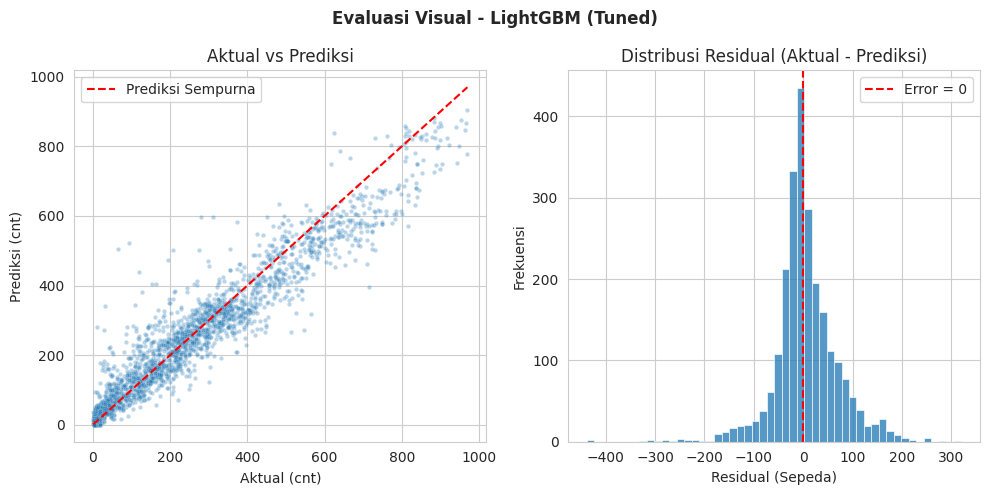


=== Analisis Residual ===

Mean Residual   : 5.01
Median Residual : -2.26
Skewness        : -0.2361
Min Residuals   : -437.98
Max Residuals   : 320.23

Residual < 0 : 1267 baris
Residual > 0 : 1164 baris
Residual = 0 : 0 baris


In [58]:
# Visualisasi Aktual vs Prediksi
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot 1: Scatter Aktual vs Prediksi
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, s=10, ax=axes[0])
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=1.5, label='Prediksi Sempurna'
)
axes[0].set_title('Aktual vs Prediksi')
axes[0].set_xlabel('Aktual (cnt)')
axes[0].set_ylabel('Prediksi (cnt)')
axes[0].legend()

# Plot 2: Distribusi Residual
residuals = y_test.values - y_pred

sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Error = 0')
axes[1].set_title('Distribusi Residual (Aktual - Prediksi)')
axes[1].set_xlabel('Residual (Sepeda)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.suptitle('Evaluasi Visual - LightGBM (Tuned)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Analisis Distribusi Residual
print()
print("=== Analisis Residual ===\n")
print(f"Mean Residual   : {residuals.mean():.2f}")
print(f"Median Residual : {np.median(residuals):.2f}")
print(f"Skewness        : {pd.Series(residuals).skew():.4f}")
print(f"Min Residuals   : {residuals.min():.2f}")
print(f"Max Residuals   : {residuals.max():.2f}")

# Frekuensi di Kiri vs Kanan
print()
print(f"Residual < 0 : {(residuals < 0).sum()} baris")
print(f"Residual > 0 : {(residuals > 0).sum()} baris")
print(f"Residual = 0 : {(residuals == 0).sum()} baris")


## 📊 5.5.3.1 Interpretasi Evaluasi Visual

**Scatter Plot (Aktual vs Prediksi):**
- Titik-titik secara umum mengikuti garis prediksi sempurna -- Menunjukkan model mampu menangkap pola demand dengan baik secara keseluruhan.
- Di range demand rendah hingga menengah (0-400), sebaran titik sangat rapat di sekitar garis -- Model konsisten dan akurat untuk kondisi normal.
- Di range demand tinggi (>500), sebaran titik mulai melebar -- Model cenderung kurang presisi saat demand sangat tinggi, terutama di jam rush hour dan lonjakan ekstrem.

**Distribusi Residual:**
- Puncak distribusi berada di sekitar nol (Mean: 5.01 & Median: -2.26) -- Model tidak memiliki bias sistematis yang signifikan, meski sedikit lebih condong ke arah over-predict.
- Jumlah error positif dan negatif tidak seimbang (Over-Predict: 1267 jam, Under-Predict: 1164 jam) -- Model sedikit lebih sering over-predict, namun selisihnya tidak terlalu besar.
- Skewness -0.24 menunjukkan distribusi lebih condong ke kiri dengan ekor kiri lebih panjang (Min: -437.98 vs Max: +320.23) -- Ada sejumlah kecil jam dengan error over-predict yang lebih ekstrem, namun frekuensinya sangat kecil.
- Selisih antara RMSE (64.50) dan MAE (43.91) mengindikasikan error ekstrem di kedua ujung ekor menarik RMSE lebih tinggi dari MAE.

**Implikasi Operasional:**
- Untuk kondisi normal, prediksi model cukup andal sebagai acuan operasional.
- Kecenderungan over-predict mengindikasikan operator perlu mempertimbangkan buffer stok yang lebih konservatif di jam-jam dengan fluktuasi demand tinggi.

## 5.5.4 Feature Importance

Analisis feature importance menunjukkan seberapa besar kontribusi setiap fitur dalam membentuk prediksi model LightGBM Tuned.

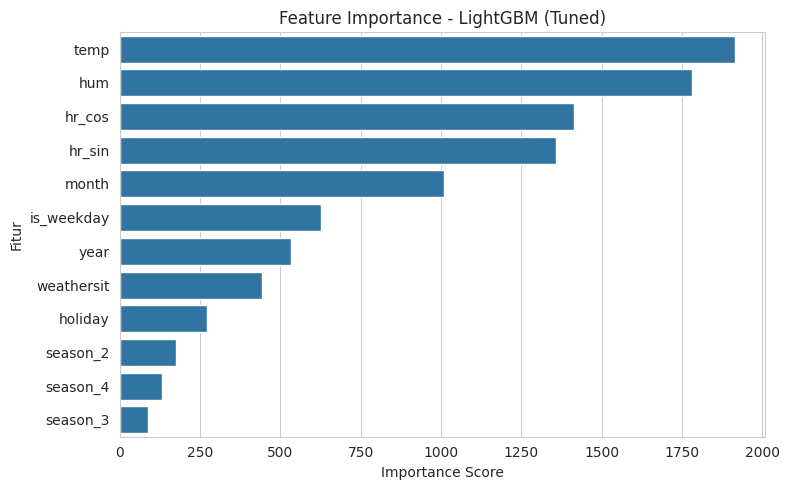


     Fitur  Importance
      temp        1914
       hum        1780
    hr_cos        1414
    hr_sin        1358
     month        1008
is_weekday         627
      year         533
weathersit         444
   holiday         272
  season_2         175
  season_4         131
  season_3          88


In [59]:
# Ambil Nama Fitur dan Nilai Importance dari Final Model
feature_names     = X_train.columns.tolist()
importance_values = final_model.named_steps['model'].feature_importances_

# Buat DataFrame dan Urutkan dari yang Paling Penting
importance_df = pd.DataFrame({
    'Fitur'      : feature_names,
    'Importance' : importance_values
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))

# Plot Horizontal Bar Chart
sns.barplot(
    data=importance_df, x='Importance', y='Fitur',
    order=importance_df['Fitur'],
    ax=ax
)
ax.set_title('Feature Importance - LightGBM (Tuned)')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Fitur')

plt.tight_layout()
plt.show()

# Tampilkan Tabel Angka
print()
print(importance_df.to_string(index=False))


## 📊 5.5.4.1 Interpretasi Feature Importance

Berdasarkan importance score dari LightGBM Tuned, fitur-fitur dapat dikelompokkan menjadi tiga tingkatan kontribusi:

**Fitur Dominan (Score > 1000):**
- **`temp` dan `hum`** menempati posisi teratas (1914 dan 1780) meskipun korelasi linearnya dengan `cnt` tergolong lemah di EDA (r = 0.40 dan r = -0.32). LightGBM berhasil menemukan pola non-linear dari kedua fitur ini yang tidak terdeteksi oleh korelasi Pearson -- Nilai suhu dan kelembaban tertentu memisahkan kelompok demand dengan sangat tajam, misalnya antara kondisi yang nyaman dan tidak nyaman untuk bersepeda. Ini mengonfirmasi bahwa tree-based model lebih tepat untuk dataset ini dibanding model linear.

- **`hr_cos` dan `hr_sin`** berada di posisi 3 dan 4 (1414 dan 1358) -- Jam adalah faktor temporal terkuat yang memengaruhi pola demand. Cyclical encoding terbukti efektif mempertahankan informasi pola jam secara utuh bagi model.

- **`month`** (1008) lebih informatif dibanding `season` -- Granularitas per bulan menangkap pola musiman dengan lebih detail dibanding kategori musim yang lebih kasar.

**Fitur Pendukung (Score 400 - 700):**
- **`is_weekday`** (627) konsisten dengan temuan EDA bahwa pola demand weekly memiliki karakter berbeda (Bimodal vs Unimodal pada weekend).

- **`year`** (533) membantu model membedakan level demand antara 2011 dan 2012, konsisten dengan growth trend yang ditemukan di EDA. Namun karena hanya berisi dua nilai, kemampuan prediksi untuk tahun di luar periode ini tidak bisa dijamin -- Dibahas lebih lanjut di Limitation.

- **`weathersit`** (444) berpengaruh secara konsisten terhadap demand sesuai temuan EDA.

**Fitur dengan Pengaruh Rendah (Score < 400):**
- **`holiday`** (272) konsisten dengan temuan EDA bahwa perbedaan demand antara hari libur dan hari biasa relatif kecil.

- **`season_2`, `season_4`, `season_3`** (175, 131, 88) masing-masing sangat kecil setelah di-encode. Informasi musiman sudah tertangkap secara lebih lengkap oleh `month`.

## 5.5.5 Analisis Error per Segmen Waktu

Memecah MAE keseluruhan berdasarkan kelompok jam untuk memahami di kondisi mana model lebih atau kurang akurat.

In [60]:
# Ambil Jam dari df Asli Menggunakan Index Test Set
test_idx = X_test.index
hr_test  = df.loc[test_idx, 'hr']
errors   = np.abs(y_test.values - y_pred)

# Buat DataFrame Analisis
error_df = pd.DataFrame({
    'hr'       : hr_test.values,
    'error'    : errors,
    'aktual'   : y_test.values,
    'prediksi' : y_pred
})

# Segmen Waktu Berdasarkan Pola EDA Section 3.2.1
def get_segmen(hr):
  if 6 <= hr <= 9:
    return 'Rush Hour Pagi (06-09)'
  elif 15 <= hr <= 20:
    return 'Rush Hour Sore (15-20)'
  elif hr >= 22 or hr <= 5:
    return 'Off-Peak (22-05)'
  else:
    return 'Normal (10-21)'

error_df['segmen'] = error_df['hr'].apply(get_segmen)

# Hitung MAE dan Jumlah Data per Segmen
segmen_stats = error_df.groupby('segmen').agg(
    mae        = ('error', 'mean'),
    jumlah_jam = ('error', 'count')
).round(2).sort_values('mae', ascending=False)

segmen_stats.columns = ['MAE', 'Jumlah Jam']

print("Analisis Error per Segmen Waktu:")
print('=' * 42)
print(segmen_stats.to_string())
print()
print(f"MAE Keseluruhan : {errors.mean():.2f} sepeda")

Analisis Error per Segmen Waktu:
                           MAE  Jumlah Jam
segmen                                    
Rush Hour Pagi (06-09) 47.6900         391
Normal (10-21)         44.3700         614
Off-Peak (22-05)       42.9400         824
Rush Hour Sore (15-20) 42.3300         602

MAE Keseluruhan : 43.91 sepeda


## 📊 5.5.5.1 Interpretasi Analisis Error per Segmen Waktu

Hasil analisis menunjukkan perbedaan MAE antar segmen waktu yang relatif kecil -- Rentang antara segmen tertinggi (Rush Hour Pagi, MAE 47.69) dan terendah (Rush Hour Sore, MAE 42.33) hanya selisih 5.36 sepeda, dengan MAE Keseluruhan sebesar 43.91 sepeda. Model cukup konsisten di seluruh kondisi waktu tanpa ada satu segmen yang jauh lebih buruk dari lainnya.

Rush Hour Pagi memiliki MAE tertinggi (47.69) dengan jumlah data paling sedikit di antara semua segmen (391 jam) -- Sedikitnya data di segmen ini berpotensi membatasi kemampuan model dalam mempelajari pola demand secara menyeluruh di jam-jam tersebut.

Rush Hour Sore memiliki MAE terendah (42.33) meski demand-nya juga tinggi -- Dengan jumlah data yang lebih banyak (602 jam) dibanding Rush Hour Pagi, model memiliki lebih banyak contoh untuk mempelajari pola demand di segmen ini.

Konsistensi MAE antar segmen ini mengonfirmasi bahwa operator tidak perlu menerapkan strategi buffer yang sangat berbeda per segmen -- Buffer proporsional dengan level demand masing-masing segmen sudah cukup sebagai antisipasi.

## 💾 Save Final Model

In [61]:
# Simpan Final Model ke Direktori Keja
MODEL_PATH = 'bike_sharing_demand_lgbm.pkl'
joblib.dump(lgbm_best.best_estimator_, MODEL_PATH)

print(f"✅ Final Model Tersimpan: {MODEL_PATH}")


✅ Final Model Tersimpan: bike_sharing_demand_lgbm.pkl


# **6. Conclusion**

## 6.1 Pencapaian Goals

| Target | Hasil | Status |
|---|---|---|
| RMSE minimal 50% lebih baik dari baseline LR | LR: 164.13 -> LightGBM: 64.50 (↓ 61%) | ✅ |
| MAE lebih baik dari 50% naive baseline (≤ 87.63) | MAE: 43.91 (↓ 75% dari naive 175.27) | ✅ |
| R² di atas 0.85 | R²: 0.9144 | ✅ |

Ketiga target berhasil dipenuhi. RMSE 61% lebih baik dari baseline Linear Regression membuktikan model mampu menangkap pola non-linear yang tidak bisa ditangkap model sederhana. MAE 43.91 melampaui target dengan improvement 75% dari naive baseline, membuktikan model telah mempelajari pola demand yang sesungguhnya dan memberikan nilai prediktif yang nyata dibanding pendekatan tanpa model.

## 6.2 Dampak Terhadap Operasional Bisnis

Model ini menggeser cara operator merencanakan distribusi sepeda -- Dari reaktif berbasis intuisi menjadi proaktif berbasis prediksi per jam yang terukur. Dengan mengetahui estimasi demand sebelum jam operasional dimulai, operator dapat mengalokasikan van rebalancing lebih efisien dan mengurangi ketidakseimbangan supply-demand yang tidak terantisipasi.

Selisih prediksi rata-rata 44 sepeda per jam (MAE 43.91) perlu tetap diperhitungkan sebagai buffer dalam perencanaan -- Khususnya di jam-jam dengan fluktuasi demand tinggi.

## 6.3 Kapan Model Dapat Dipercaya

Model paling andal digunakan pada kondisi berikut:

- **Seluruh segmen waktu operasional** -- Analisis error per segmen menunjukkan MAE yang konsisten di seluruh kondisi waktu (42-48 sepeda), tanpa ada satu segmen yang jauh lebih buruk dari lainnya. Rush Hour Pagi memiliki error tertinggi (MAE 47.69) namun perbedaannya tidak signifikan dibanding segmen lain.
- **Kondisi cuaca yang pernah dilihat model** -- Cuaca cerah hingga hujan ringan (weathersit 1-3).
- **Hari kerja dan akhir pekan** -- Model sudah dilatih dengan pola keduanya secara seimbang.

## 6.4 Limitasi Model

**Dari Sisi Data:**
- Dataset hanya mencakup 2011-2012 -- Model hanya mengenal kondisi dan level demand pada periode tersebut. Karena fitur `year` hanya berisi dua nilai, prediksi untuk tahun berikutnya tidak bisa dijamin dan model perlu di-retrain secara berkala dengan data terbaru agar tetap relevan.
- `weathersit - 4` (Cuaca ekstrem) hanya 3 baris -- Prediksi untuk kondisi ini tidak dapat diandalkan.
- Dataset tidak mencakup faktor eksternal seperti event kota, gangguan transportasi publik, atau kondisi khusus lainnya yang dapat memengaruhi demand secara signifikan -- Menjadi salah satu penyebab error ekstrem yang sesekali terjadi.

**Dari Sisi Model:**
- Model memprediksi total demand di tingkat sistem, bukan per stasiun -- Tidak bisa langsung digunakan untuk menentukan redistribusi sepeda antar stasiun secara spesifik.
- Model dapat menghasilkan prediksi bernilai negatif pada jam-jam dengan demand sangat rendah karena regression tree tidak memiliki constraint non-negatif secara native. Untuk keperluan operasional, prediksi negatif di-clip ke 0 sebagai langkah koreksi sebelum digunakan.
- Feature importance menunjukkan `season` memiliki importance score yang sangat rendah dibanding `month` -- Informasi musiman tampaknya sudah tertangkap lebih baik oleh granularitas per bulan, sehingga `season` berpotensi redundan sebagai fitur model.

# **7. Recommendation**

## 7.1 Rekomendasi Penggunaan Model

Model paling tepat digunakan sebagai **alat bantu perencanaan distribusi sepeda** sebelum jam-jam operasional dimulai, bukan sebagai satu-satunya dasar keputusan.

- Di jam-jam normal di luar rush hour, prediksi model sudah cukup andal untuk dijadikan acuan langsung dalam menentukan jumlah sepeda yang perlu disiapkan.
- Di jam rush hour (06-09), model menghasilkan MAE tertinggi (47.69 sepeda) -- Disarankan menambahkan buffer stok sebagai antisipasi karena lonjakan demand di segmen ini paling tajam.
- Pada kondisi cuaca ekstrem (weathersit = 4), prediksi model tidak dapat diandalkan karena data untuk kondisi ini hampir tidak ada di training set.

## 7.2 Rekomendasi Peningkatan Model

**Data:**
- Model perlu di re-train secara berkala dengan data terbaru agar prediksinya tetap relevan seiring pertumbuhan pengguna dan perubahan pola demand.
- Menyelesaikan masalah rebalancing secara lebih spesifik membutuhkan data penyewaan per stasiun -- Model saat ini hanya memprediksi total demand di tingkat sistem secara keseluruhan.

**Fitur:**
- Penambahan fitur eksternal seperti data event kota (konser, hari besar, car free day) berpotensi meningkatkan akurasi prediksi karena event-event ini dapat memengaruhi pola demand secara signifikan dan tidak tertangkap oleh fitur yang tersedia saat ini.
- Fitur `season` berpotensi dihapus pada iterasi berikutnya karena importance score-nya sangat rendah dibanding `month` -- Informasi musiman tampaknya sudah tertangkap lebih baik oleh granularitas per bulan, sehingga `season` berpotensi redundan.

**Operasional:**
- Model saat ini sudah bisa digunakan untuk prediksi demand dengan input cuaca yang diambil secara manual dari sumber seperti freemeteo -- Sumber yang sama dengan data cuaca di dataset ini. Untuk meningkatkan efisiensi operasional, direkomendasikan mengintegrasikan API forecast cuaca ke dalam pipeline otomatis sehingga prediksi demand per jam dapat dihasilkan setiap malam tanpa intervensi manual, mengurangi risiko human error, dan memungkinkan update prediksi lebih sering seiring perubahan kondisi cuaca.

**Evaluasi:**
- Analisis error per segmen waktu menunjukkan konsistensi MAE yang relatif merata -- Eksplorasi lebih lanjut dapat dilakukan per segmen weekday vs weekend untuk memahami apakah pola serupa berlaku di kedua kondisi tersebut.